# Notebook 03, Topic Modeling & Thematic Analysis

**Project:** Thematic Evolution of French Electoral Manifestos (1973–1993)  
**Course:** Machine Learning for NLP, ENSAE Paris, 2025–2026  
**Author:** Gabriel Orsatti

---

## Motivation & Approach

Topic modeling is a family of unsupervised methods for discovering latent thematic structure in document collections. As Blei (2012) defines it, a topic is a *distribution over a fixed vocabulary*, and each document exhibits multiple topics in different proportions. The course (Lesson 6 - Topic Modelling) introduces two main approaches:

- **LDA**: a *probabilistic generative model* where each document is a mixture of topics drawn from Dirichlet priors, and each topic is a distribution over words. The generative process (Lesson 6 - Topic Modelling): *(1) choose a distribution over topics; (2) for each word, choose a topic, then choose a word from that topic.*
- **NMF**: a *linear algebra factorization* $V \approx W \times H$ where $W$ is the document-topic matrix and $H$ the topic-word matrix. Unlike LDA, NMF has *"no probabilistic assumptions"* (Lesson 6 - Topic Modelling, comparison table) and operates on TF-IDF rather than raw counts.

We add a third paradigm, **BERTopic**, which leverages pre-trained Transformer embeddings ((Lesson 7 - Transformers)) to capture semantic similarity beyond bag-of-words co-occurrence.

**Key design choices:**
1. Each model is trained at **its own optimal $k$**, selected via $C_v$ coherence, *"the metric most correlated with human ratings"* (Röder et al., 2015; Lecon 6 - Topic Modelling)
2. The **primary model for cross-analysis** is selected by combining Cv with **distribution balance**, a degenerate model (80%+ of docs in one topic) is rejected even if its Cv is high
3. A two-stage approach: **baseline LDA on full vocabulary** (diagnostic) → **improved models on clean vocabulary** (partisan stopwords removed)

**Checkpoint system:** Expensive computations cached in `../data/checkpoints/`.

---

## Table of Contents

1. Environment & Data Preparation
2. Lemmatization with spaCy
3. Baseline LDA (full vocabulary), diagnostic
4. Improved Models: optimal $k$ selection, final LDA & NMF
5. BERTopic (embedding-based)
6. Quantitative Model Comparison
7. Cross-Analysis: Topics × Metadata
8. Save & Summary

---
## 1. Environment & Data Preparation
### 1.1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from pathlib import Path
import re, string, os, pickle, json, time, ast
from collections import Counter
import urllib.request
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.manifold import TSNE

CHECKPOINT_DIR = Path("../data/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_pickle("../data/df_explore.pkl")
print(f"DataFrame loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"Years: {sorted(df['year'].unique())}")

DataFrame loaded: 21,697 rows × 52 columns
Years: ['1973', '1978', '1981', '1988', '1993']


**Methodological note: LDA and CountVectorizer.**
The choice of `CountVectorizer` (raw term frequencies) over `TfidfVectorizer` is deliberate. LDA is a *generative* probabilistic model: it assumes documents are generated by first sampling a topic distribution from a Dirichlet prior, then sampling words from each topic's multinomial distribution. Raw counts are the natural input for this generative process.

The hyperparameters `max_features`, `min_df`, `max_df` control the vocabulary size. `ngram_range=(1, 2)` includes both unigrams and bigrams, capturing multi-word expressions like "peine de mort" or "parti socialiste".

### 1.2 Visual style

In [2]:
FONT_DIR = os.path.expanduser("~/.fonts")
os.makedirs(FONT_DIR, exist_ok=True)
for name, url in {
    "Playfair Display": "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "Source Sans 3": "https://github.com/google/fonts/raw/main/ofl/sourcesans3/SourceSans3%5Bwght%5D.ttf",
}.items():
    path = os.path.join(FONT_DIR, f"{name}.ttf")
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Playfair Display.ttf"))
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Source Sans 3.ttf"))

FONT_TITLE = 'Playfair Display'
FONT_BODY = 'Source Sans 3'
FAMILY_COLORS = {
    'Gauche radicale':  '#C0392B',
    'Gauche modérée':   '#E8919A',
    'Écologistes':      '#27AE60',
    'Centre':           '#F0B87E',
    'Droite':           '#5B8DB8',
    'Extrême droite':   '#2C3E50',
    'Autre':            '#A89F96',
}
FAMILIES = ['Gauche radicale', 'Gauche modérée', 'Écologistes', 'Centre', 'Droite', 'Extrême droite']
YEAR_COLORS = {
    '1973': '#C9A891',
    '1978': '#8BA89D',
    '1981': '#D4626E',
    '1988': '#7EADD4',
    '1993': '#5B8DB8'
}
BG_COLOR = '#FAF7F2'; TEXT_COLOR = '#2C2824'; GRID_COLOR = '#E8E4DD'
plt.rcParams.update({
    'figure.facecolor': BG_COLOR, 'axes.facecolor': BG_COLOR,
    'axes.edgecolor': GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'text.color': TEXT_COLOR, 'xtick.color': TEXT_COLOR, 'ytick.color': TEXT_COLOR,
    'grid.color': GRID_COLOR, 'grid.alpha': 0.5, 'font.family': FONT_BODY,
    'font.size': 11, 'axes.titlesize': 16, 'axes.labelsize': 12,
    'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False})
print("Style configured ✓")

Style configured ✓


### 1.3 Text preparation & language filtering

We filter documents shorter than 100 characters and remove German-language manifestos from Alsace-Moselle (bilingual electoral tradition). These would create a spurious "German language" topic unrelated to French political themes.

In [3]:
if 'text_clean' not in df.columns:
    def clean_text(text):
        if not isinstance(text, str): return ""
        text = text.lower().replace('\n', ' ').replace('\r', ' ')
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        return re.sub(r'\s+', ' ', text).strip()
    df['text_clean'] = df['text'].apply(clean_text)

df_topic = df[df['text_clean'].str.len() > 100].copy()

def is_french(text):
    if not isinstance(text, str): return False
    german = ['die', 'der', 'und', 'für', 'den', 'sie', 'das', 'ist', 'von']
    words = text.lower().split()
    if len(words) == 0: return False
    return sum(1 for w in words if w in german) / len(words) < 0.05

mask_fr = df_topic['text_clean'].apply(is_french)
df_topic = df_topic[mask_fr].copy()
print(f"Documents retained: {len(df_topic):,} (filtered {(~mask_fr).sum()} German-language docs)")

Documents retained: 21,139 (filtered 556 German-language docs)


---
## 2. Lemmatization with spaCy

The course recommends the pipeline (Lesson 6 - Topic Modelling): `Lemmatization + Stop Words + CountVectorizer + LDA`. Lemmatization reduces inflected forms to their *"canonical form, dictionary form, or citation form"* (Lesson 4 - Computational Linguistics), unlike stemming which *"chops off the ends of words"* and may produce non-words.

We use spaCy's `fr_core_news_md`, a French model trained on newspaper text, well-suited to our political corpus. The course notes (Lesson 4 - Computational Linguistics)) that *"in practice, stemming is a crude and incorrect approximation of lemmatization"*, we therefore opt for the more accurate approach.

In [4]:
pip install spacy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "spacy", "download", "fr_core_news_md"], check=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/45.8 MB ? eta -:--:--


     ━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━ 18.1/45.8 MB 107.3 MB/s eta 0:00:01


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 41.4/45.8 MB 111.2 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 79.3 MB/s  0:00:00


✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')


CompletedProcess(args=['/opt/python/bin/python', '-m', 'spacy', 'download', 'fr_core_news_md'], returncode=0)

In [6]:
CHECKPOINT_LEMMA = CHECKPOINT_DIR / "lemmatized_tokens.json"

if CHECKPOINT_LEMMA.exists():
    with open(CHECKPOINT_LEMMA, 'r') as f:
        token_lists = json.load(f)
    
    if len(token_lists) == len(df_topic):
        df_topic['tokens_lemma'] = token_lists
        print(f"✓ Lemmatized tokens loaded from cache ({len(token_lists):,} docs)")
    else:
        print(f"⚠ Cache size mismatch: {len(token_lists):,} cached vs {len(df_topic):,} docs in corpus.")
        print(f"  Cache outdated (old corpus without 1973/1978) → deleting and re-lemmatizing...")
        CHECKPOINT_LEMMA.unlink()
        token_lists = None  # force the else branch below

if not CHECKPOINT_LEMMA.exists():
    import spacy
    nlp_spacy = spacy.load("fr_core_news_md", disable=["ner", "parser"])
    STOPWORDS_ALL = set(nlp_spacy.Defaults.stop_words)
    STOPWORDS_ALL.update({
        'être', 'avoir', 'faire', 'plus', 'tout', 'aussi', 'très', 'bien',
        'encore', 'tant', 'rien', 'autre', 'même', 'non', 'oui', 'comme',
        'politique', 'france', 'français', 'française', 'république',
        'candidat', 'élection', 'vote', 'voter', 'circonscription',
        'député', 'suppléant', 'conseiller', 'maire', 'président',
        'falloir', 'pouvoir', 'devoir', 'savoir', 'vouloir', 'venir', 'aller',
        'janvier', 'février', 'mars', 'avril', 'mai', 'juin',
        'juillet', 'août', 'septembre', 'octobre', 'novembre', 'décembre',
    })
    print(f"Lemmatizing {len(df_topic):,} documents...")
    t0 = time.time()
    token_lists = []
    for i, doc in enumerate(nlp_spacy.pipe(df_topic['text_clean'], batch_size=500, n_process=1)):
        tokens = [token.lemma_.lower() for token in doc
                  if not token.is_stop and token.lemma_.lower() not in STOPWORDS_ALL
                  and len(token.lemma_) > 2 and token.is_alpha]
        token_lists.append(tokens)
        if (i + 1) % 2000 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i + 1) * (len(df_topic) - i - 1)
            print(f"  {i+1:,}/{len(df_topic):,} | {elapsed/60:.1f}min | ETA: {eta/60:.1f}min")
    df_topic['tokens_lemma'] = token_lists
    with open(CHECKPOINT_LEMMA, 'w') as f:
        json.dump(token_lists, f, ensure_ascii=False)
    print(f"✓ Done ({time.time()-t0:.0f}s)")

print(f"Sample: {token_lists[0][:12]}")

✓ Lemmatized tokens loaded from cache (21,139 docs)
Sample: ['science', 'fonds', 'cevipof', 'republiqu', 'departement', 'hautesavoie', 'annemassechamonix', 'scrutin', 'ballottage', 'lucien', 'coutant', 'mouvement']


---
## 3. Baseline LDA (Full Vocabulary, k=12)

Before any vocabulary cleaning, we train a standard LDA to observe what the model captures "out of the box". This serves as a **diagnostic step**, we expect the model to latch onto the most statistically distinctive word groups, which in a political corpus means party-specific jargon.

### 3.1 Utility function

In [7]:
def get_topic_words(model, feature_names, n_words=15):
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        topics[idx] = [feature_names[i] for i in top_indices]
    return topics

### 3.2 Baseline model

Following the course pipeline (Ref: Lecon 6 - Topic Modelling): `CountVectorizer + Stop Words + LatentDirichletAllocation`.

In [8]:
STOPWORDS_BASE = [
    'le','la','les','de','des','du','un','une','et','en','à','au','aux','ce','ces',
    'que','qui','dans','pour','par','sur','avec','son','ses','sa','se','ne','pas',
    'nous','vous','ils','est','sont','ont','été','être','avoir','fait','faire','plus',
    'tout','tous','toute','toutes','mais','ou','où','si','leur','leurs','elle','elles',
    'il','je','me','mon','ma','mes','notre','nos','votre','vos','même','aussi','bien',
    'peut','cette','cet','dont','comme','sans','entre','très','après','avant','autres',
    'autre','encore','quand','car','donc','sera','non','oui','puis','ici','là','ya',
    'ça','cela','ceci','on','ny','na','ni','peu','chaque','sous','depuis','eux','lui',
    'celle','ceux','celui','quelques','tant','ainsi','vers','chez','contre','dès','trop',
    'lors','déjà','soit','afin','tel','telle','cest','quil','quils','dune','dun','jai',
    'lassemblée','nationale','national','suis','nest','naura','quon',
    'circonscription','candidat','candidate','élections','législatives',
    'république','française','france','département','juin','mars',
    'tour','scrutin','vote','voter','électeurs','électeur',
    'profession','foi','premier','première','second','seconde',
    'nom','prénom','année','années','ans','deux','trois',
    'faut','doit','peuvent','doivent','falloir','pouvoir',
    'devoir','aller','dire','voir','vouloir','savoir',
]
count_vectorizer = CountVectorizer(max_features=5000, min_df=10, max_df=0.7,
    stop_words=STOPWORDS_BASE, ngram_range=(1, 2))
count_matrix = count_vectorizer.fit_transform(df_topic['text_clean'])
feature_names = count_vectorizer.get_feature_names_out()
N_TOPICS_BASELINE = 12
lda_baseline = LatentDirichletAllocation(n_components=N_TOPICS_BASELINE, max_iter=30,
    learning_method='online', random_state=42, n_jobs=-1)
lda_baseline_topics = lda_baseline.fit_transform(count_matrix)
print(f"Baseline LDA: {count_matrix.shape}, k={N_TOPICS_BASELINE}")
print(f"\n=== Baseline Topics ===\n")
for tid, words in get_topic_words(lda_baseline, feature_names, 10).items():
    print(f"Topic {tid:2d}: {', '.join(words)}")

Baseline LDA: (21139, 5000), k=12

=== Baseline Topics ===

Topic  0: écologistes, lécologie, ecologistes, verts, vie, entente, davenir, chômage, nouvelle, lentente
Topic  1: majorité, député, maire, conseiller, président, général, suppléant, confiance, socialiste, conseiller général
Topic  2: français, votez, nature, animaux, voulez, voix, code, impôts, ludf, rpr
Topic  3: travailleurs, lutte, marchais, lutte ouvrière, suppléant, travailleuses travailleurs, ouvriere, candidats, lutte ouvriere, mitterrand
Topic  4: front, rpr, pc, force, cevipov, fonds cevipov, ludf, rpr ludf, ps pc, suppression
Topic  5: travailleurs, petits, gauche, mitterrand, commerçants, petits commerçants, parti, gouvernement, députés, lutte
Topic  6: travailleurs, femmes, travail, socialisme, lautogestion, société, psu, droit, nucléaire, ps
Topic  7: droite, moi, aujourdhui, politique, hommes, toujours, pays, demain, chirac, besoin
Topic  8: présidentielle, français, majorité présidentielle, front, majorité, jus

**Diagnosis:** The baseline LDA confirms our hypothesis, it captures **partisan identities** rather than policy themes. The FN's distinctive vocabulary (immigration, insécurité, front national), the PCF's discourse (travailleurs, lutte, ouvrier), and the ecology movement's jargon (nature, animaux, écologie) each form separate topics. Only 1–2 topics out of 12 represent genuine cross-partisan policy content.

This is expected: as the course's LDA generative model shows (Lesson 6 - Topic Modelling), LDA finds the word distributions that best explain the observed data. When party-specific vocabulary is highly distinctive, it dominates the latent structure.

**→ Solution:** Remove partisan vocabulary to force the model to discover *substantive* policy themes.

---
## 4. Improved Models (Clean Vocabulary, Optimal k)

### 4.1 Partisan stopwords

We extend the stopword list with party names, leader names, slogans, and OCR artifacts. This is analogous to the course's recommendation ((Lesson 1 - Vector Representation for NLP)): *"Remove non-informative words with a custom word list."*

In [9]:
STOPWORDS_PARTISAN = STOPWORDS_BASE + [
    'front','rpr','udf','pcf','rpf','fnr',
    'communiste','communistes','socialiste','socialistes',
    'gaulliste','gaullistes','écologiste','écologistes',
    'ecologiste','ecologistes','verts','vert',
    'radical','radicaux','centriste','centristes',
    'lutte','ouvrière','laguiller','arlette',
    'mitterrand','chirac','giscard','marchais','barre','lepen','pen',
    'parti','partis','mouvement','rassemblement','union',
    'coalition','alliance','entente','liste',
    'député','députés','suppléant','suppléante',
    'conseiller','conseillère','maire','président',
    'sénateur','assemblée','sénat','parlement',
    'candidat','candidate','candidats','candidates',
    'mandat','mandats','élu','élue','élus',
    'votez','voter','voix','bulletin','urne',
    'confiance','soutien','soutenir','appel',
    'madame','monsieur','mademoiselle','chers','concitoyens',
    'électeurs','électrices','mengage','engage','promets',
    'vive','force','davenir','avenir','convictions','populaire','ensemble',
    'gauche','droite','centre',
    'lécologie','lentente','lhomme','lunion',
    'quil','quils','quon','quelles',
    'naturelle','loi naturelle','connaissance','transcendantale','méditation',
    # Cross-partisan terms visible in LDA k=11 output
    'travailleur','travailleurs','ouvrier','ouvriers',
    'politique','français','française','françaises',
    'pays','vie','monde','homme','hommes','femme','femmes',
    'contre','droit','droits','travail','emploi','chômage',
    'programme','gouvernement','majorité','national','nationale',
    'entreprise','entreprises','petit','grands','grand',
    'public','publique','social','sociale','économique',
    'général','dun','dune','quils','quon','quil',
    'donner','maintenir','payer','rétablir',
    'loi','lois','temps','moyen','moyens',
    'impôt','impôts','faut','falloir','devoir',
]
print(f"Partisan stopwords: {len(STOPWORDS_PARTISAN)} terms")

Partisan stopwords: 334 terms


### 4.2 Gensim corpus

We use **gensim** for coherence evaluation, the course identifies it as *"specialized in topic modelling"* (Ref: Lecon 6 - Topic Modelling). Gensim provides native access to $C_v$, $C_{UMass}$, $C_{UCI}$, and $C_{NPMI}$ metrics.

In [10]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [11]:
from gensim import corpora
from gensim.models import CoherenceModel, LdaMulticore

gensim_dictionary = corpora.Dictionary(token_lists)
gensim_dictionary.filter_extremes(no_below=5, no_above=0.6)
gensim_corpus = [gensim_dictionary.doc2bow(tokens) for tokens in token_lists]
print(f"Gensim dictionary: {len(gensim_dictionary)} terms | Corpus: {len(gensim_corpus)} docs")

Gensim dictionary: 29505 terms | Corpus: 21139 docs


### 4.3 Optimal $k$ selection (grid search)

As the course emphasizes (Ref: Lecon 6 - Topic Modelling):
> *"The number of topics is a meta-parameter that needs to be optimised."*

We evaluate $C_v$ coherence, *"a metric 'discovered' through systematic experiments to find the correlation between coherence metrics and human ratings"* (Röder et al., 2015; Lecon 6 - Topic Modelling). The $C_v$ pipeline combines NPMI vectors with cosine similarity across sliding windows.

**Critical design choice:** Each model gets **its own optimal $k$**. LDA (probabilistic, with Dirichlet priors that regularize topic distributions) and NMF (algebraic, no regularization) have different statistical properties and may require different granularity. Forcing both to the same $k$ would disadvantage one model.

**NMF sensitivity note:** NMF is highly sensitive to vocabulary size. We use `min_df=15` and `max_features=3000`, using looser settings (e.g., `min_df=5`) allows rare words that cause NMF to isolate hyper-specific micro-clusters rather than cross-partisan themes.

In [12]:
CHECKPOINT_GRID = CHECKPOINT_DIR / "grid_search_v8.json"

if CHECKPOINT_GRID.exists():
    with open(CHECKPOINT_GRID, 'r') as f:
        grid = json.load(f)
    range_topics = grid['range_topics']
    lda_cv = grid['lda_cv']; lda_umass = grid['lda_umass']
    nmf_cv = grid['nmf_cv']; nmf_umass = grid['nmf_umass']
    nmf_recon = grid['nmf_recon']
    print(f"✓ Grid search loaded from cache")
else:
    range_topics = [5, 7, 9, 11, 13, 15]
    lda_cv, lda_umass = [], []
    nmf_cv, nmf_umass, nmf_recon = [], [], []

    tfidf_vec_grid = TfidfVectorizer(max_features=3000, min_df=15, max_df=0.6,
        stop_words=STOPWORDS_PARTISAN, ngram_range=(1, 2))
    tfidf_matrix_grid = tfidf_vec_grid.fit_transform(df_topic['text_clean'])
    tfidf_names_grid = tfidf_vec_grid.get_feature_names_out()

    print("=" * 70)
    print(f"Grid Search - LDA (gensim) + NMF (sklearn)")
    print(f"TF-IDF: {tfidf_matrix_grid.shape}")
    print("=" * 70)
    t0 = time.time()

    for step, k in enumerate(range_topics):
        t_step = time.time()
        lda_g = LdaMulticore(gensim_corpus, num_topics=k, id2word=gensim_dictionary,
                              passes=10, workers=2, random_state=42)
        cm1 = CoherenceModel(model=lda_g, texts=token_lists, dictionary=gensim_dictionary, coherence='c_v')
        cm2 = CoherenceModel(model=lda_g, texts=token_lists, dictionary=gensim_dictionary, coherence='u_mass')
        lda_cv.append(cm1.get_coherence()); lda_umass.append(cm2.get_coherence())

        nmf_k = NMF(n_components=k, random_state=42, max_iter=300, init='random')
        nmf_k.fit(tfidf_matrix_grid)
        nmf_recon.append(nmf_k.reconstruction_err_)
        nmf_words = [[tfidf_names_grid[j] for j in t.argsort()[-10:][::-1]] for t in nmf_k.components_]
        cm3 = CoherenceModel(topics=nmf_words, texts=token_lists, dictionary=gensim_dictionary, coherence='c_v')
        cm4 = CoherenceModel(topics=nmf_words, texts=token_lists, dictionary=gensim_dictionary, coherence='u_mass')
        nmf_cv.append(cm3.get_coherence()); nmf_umass.append(cm4.get_coherence())

        elapsed = time.time() - t0
        eta = elapsed / (step+1) * (len(range_topics) - step - 1)
        print(f"  k={k:2d} | LDA Cv={lda_cv[-1]:.4f} | NMF Cv={nmf_cv[-1]:.4f} | {time.time()-t_step:.0f}s | ETA: {eta/60:.1f}min")

    with open(CHECKPOINT_GRID, 'w') as f:
        json.dump({'range_topics': range_topics, 'lda_cv': lda_cv, 'lda_umass': lda_umass,
                   'nmf_cv': nmf_cv, 'nmf_umass': nmf_umass, 'nmf_recon': nmf_recon}, f)
    print(f"\n✓ Saved ({time.time()-t0:.0f}s)")

✓ Grid search loaded from cache


### 4.4 Evaluation plots & independent $k$ selection

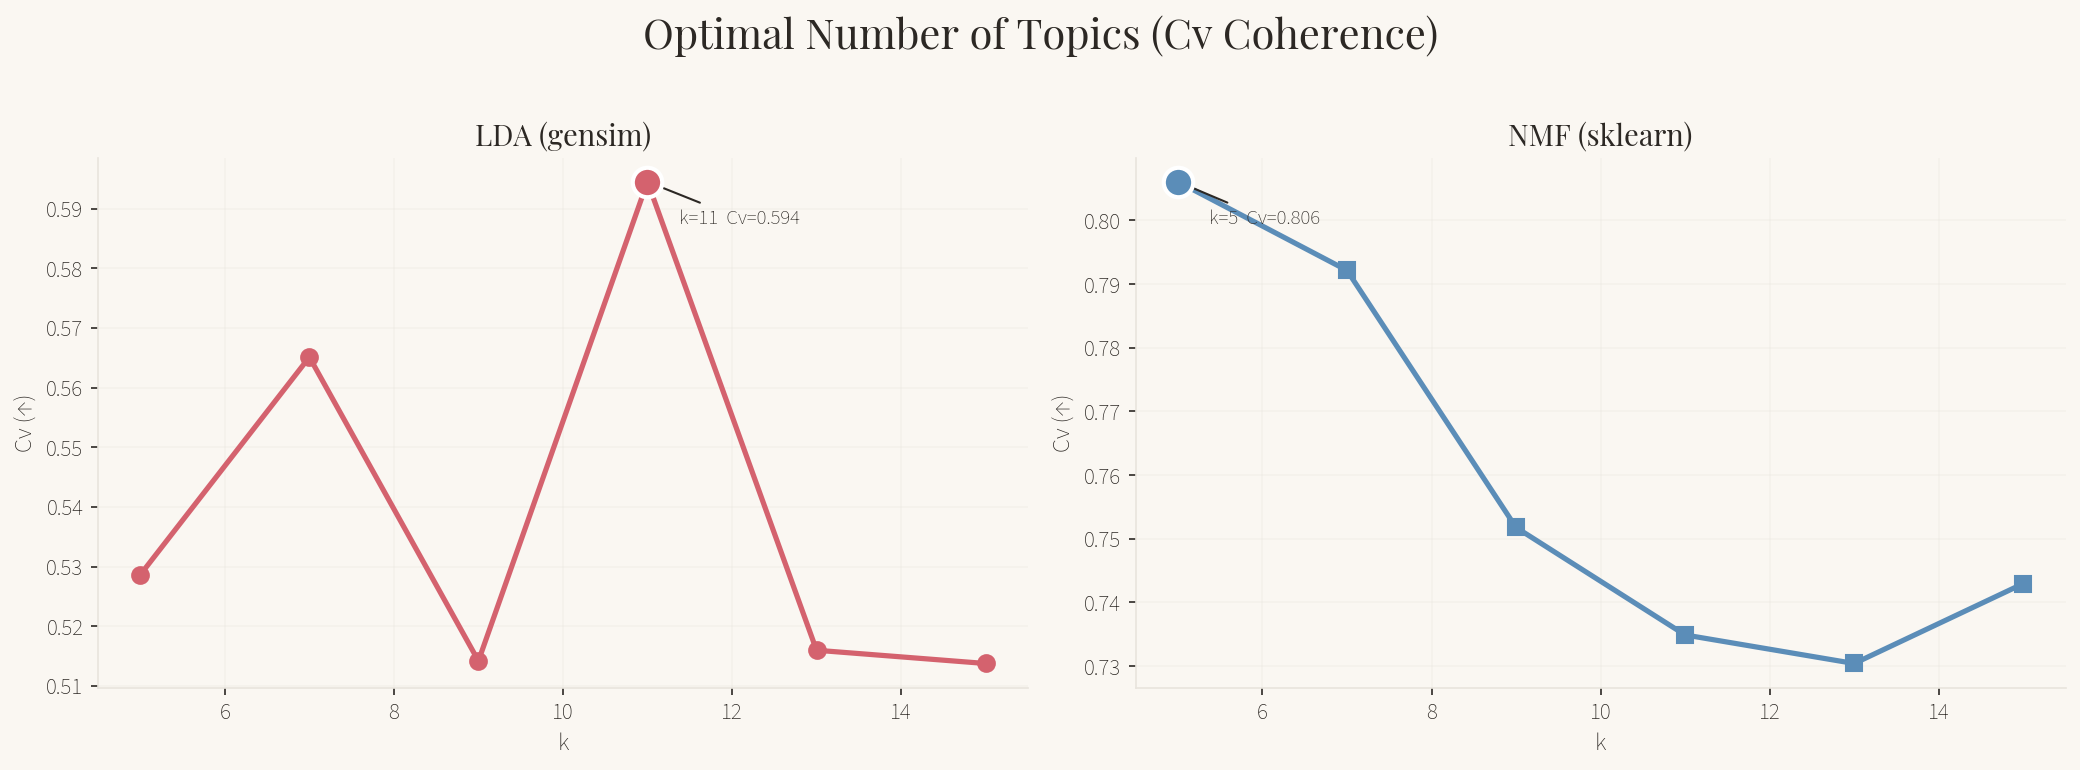

★ LDA optimal: k=11 (Cv=0.5945)
★ NMF optimal: k=5 (Cv=0.8061)


In [13]:
best_lda_idx = int(np.argmax(lda_cv))
best_nmf_idx = int(np.argmax(nmf_cv))
K_LDA = range_topics[best_lda_idx]
K_NMF = range_topics[best_nmf_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimal Number of Topics (Cv Coherence)",
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=1.02)

ax = axes[0]
ax.plot(range_topics, lda_cv, 'o-', color='#D4626E', lw=2.5, ms=8)
ax.scatter([K_LDA], [lda_cv[best_lda_idx]], s=200, color='#D4626E', zorder=5, edgecolors='white', lw=2)
ax.annotate(f'k={K_LDA}  Cv={lda_cv[best_lda_idx]:.3f}', xy=(K_LDA, lda_cv[best_lda_idx]),
            xytext=(15, -20), textcoords='offset points', fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TEXT_COLOR))
ax.set_xlabel("k"); ax.set_ylabel("Cv (↑)"); ax.set_title("LDA (gensim)", fontfamily=FONT_TITLE, fontsize=14); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range_topics, nmf_cv, 's-', color='#5B8DB8', lw=2.5, ms=8)
ax.scatter([K_NMF], [nmf_cv[best_nmf_idx]], s=200, color='#5B8DB8', zorder=5, edgecolors='white', lw=2)
ax.annotate(f'k={K_NMF}  Cv={nmf_cv[best_nmf_idx]:.3f}', xy=(K_NMF, nmf_cv[best_nmf_idx]),
            xytext=(15, -20), textcoords='offset points', fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TEXT_COLOR))
ax.set_xlabel("k"); ax.set_ylabel("Cv (↑)"); ax.set_title("NMF (sklearn)", fontfamily=FONT_TITLE, fontsize=14); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/model_evaluation.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print(f"★ LDA optimal: k={K_LDA} (Cv={lda_cv[best_lda_idx]:.4f})")
print(f"★ NMF optimal: k={K_NMF} (Cv={nmf_cv[best_nmf_idx]:.4f})")

### 4.5 Train final LDA at its optimal k

In [14]:
lda_final = LdaMulticore(gensim_corpus, num_topics=K_LDA, id2word=gensim_dictionary,
                          passes=20, workers=2, random_state=42)
print(f"=== Final LDA (k={K_LDA}) ===\n")
for idx, topic in lda_final.print_topics(num_words=10):
    print(f"Topic {idx:2d}: {topic}")

=== Final LDA (k=11) ===

Topic  0: 0.024*"quils" + 0.019*"travailleur" + 0.018*"payer" + 0.017*"patron" + 0.017*"entreprise" + 0.016*"maintenir" + 0.015*"patronat" + 0.013*"emploi" + 0.011*"chômage" + 0.011*"quon"
Topic  1: 0.019*"front" + 0.013*"force" + 0.009*"contre" + 0.009*"rpr" + 0.008*"populaire" + 0.008*"suppression" + 0.006*"confiance" + 0.006*"ludf" + 0.006*"électeur" + 0.006*"famille"
Topic  2: 0.007*"jai" + 0.007*"monsieur" + 0.006*"général" + 0.005*"confiance" + 0.005*"région" + 0.004*"homme" + 0.004*"solidarité" + 0.004*"formation" + 0.004*"majorité" + 0.004*"ensemble"
Topic  3: 0.025*"gauche" + 0.022*"communiste" + 0.017*"parti" + 0.017*"droite" + 0.013*"socialiste" + 0.011*"changement" + 0.009*"majorité" + 0.009*"monsieur" + 0.008*"force" + 0.007*"voix"
Topic  4: 0.012*"liberté" + 0.012*"majorité" + 0.007*"tour" + 0.007*"général" + 0.007*"socialiste" + 0.006*"parti" + 0.006*"électeur" + 0.005*"election" + 0.005*"progrès" + 0.005*"société"
Topic  5: 0.029*"travailleur" 

### 4.6 Train final NMF at its optimal k

In [15]:
tfidf_vec_clean = TfidfVectorizer(max_features=3000, min_df=15, max_df=0.6,
    stop_words=STOPWORDS_PARTISAN, ngram_range=(1, 2))
tfidf_matrix_clean = tfidf_vec_clean.fit_transform(df_topic['text_clean'])
tfidf_features_clean = tfidf_vec_clean.get_feature_names_out()
nmf_final = NMF(n_components=K_NMF, random_state=42, max_iter=300, init='random')
W_nmf = nmf_final.fit_transform(tfidf_matrix_clean)
print(f"TF-IDF: {tfidf_matrix_clean.shape}")
print(f"\n=== Final NMF (k={K_NMF}) ===\n")
for i, topic in enumerate(nmf_final.components_):
    words = [tfidf_features_clean[j] for j in topic.argsort()[-10:][::-1]]
    print(f"Topic {i:2d}: {', '.join(words)}")

TF-IDF: (21139, 3000)

=== Final NMF (k=5) ===

Topic  0: petits, travailleuses, petits commerçants, ouvriere, bombe atomique, bombe, atomique, commerçants, paysans, alors
Topic  1: jusquici, ludf, suppression, faites, fois sentendra, effectivement lequel, défende liberté, travaille créer, préoccuper intérêts, sentendra
Topic  2: changement, commun, progrès, société, nouvelle, liberté, développement, enfants, jeunes, région
Topic  3: animaux, nature, nature animaux, nouveaux nature, nouveaux, marseille, ruffi marseille, trouvent bulletins, engagement documenta, abus chasse
Topic  4: supprimant, ludf, voulez, sauver, carte, immigrés, limmigration, nationalité, bas, millions


### 4.7 Topic naming & quality assessment

*"Topic modelling is unsupervised and requires human interpretation. For human interpretation, the number of topics and the number of topic words should not be too large."* (Lecon 6 - Topic Modelling)

In [ ]:
TOPIC_NAMES_LDA = {
    0: "Rapports de force patronat/salariés",
    1: "Coalition de droite (RPR/UDF)",             
    2: "Appel institutionnel & Discours local",     
    3: "Clivage partisan & Alliances de gauche",
    4: "Valeurs républicaines & Appel au 2nd tour", 
    5: "Lutte des classes & Droits ouvriers",
    6: "Protection sociale & Retraites",
    7: "Écologie politique & Citoyenneté",
    8: "Immigration", 
    9: "Mobilisation Mitterrandiste (1981)",
    10: "Enjeux sociétaux (Féminisme/Nucléaire)"
}

TOPIC_NAMES_NMF = {
    0: "Extrême-gauche ouvrière & Pacifisme",       
    1: "Opposition libérale (UDF/Droite)",          
    2: "Programme Commun & Progrès (Gauche)",       
    3: "Protection animale & Micro-partis locaux", 
    4: "Nationalisme & Immigration (FN)"           
}

# Assign LDA topics
lda_doc_topics = [lda_final.get_document_topics(bow, minimum_probability=0) for bow in gensim_corpus]
df_topic['lda_topic'] = [max(dt, key=lambda x: x[1])[0] for dt in lda_doc_topics]
df_topic['lda_topic_name'] = df_topic['lda_topic'].map(TOPIC_NAMES_LDA)

# Assign NMF topics
df_topic['nmf_topic'] = W_nmf.argmax(axis=1)
df_topic['nmf_topic_name'] = df_topic['nmf_topic'].map(TOPIC_NAMES_NMF)

print(f"=== LDA (k={K_LDA}) distribution ===")
print(df_topic['lda_topic_name'].value_counts())
print(f"\n=== NMF (k={K_NMF}) distribution ===")
print(df_topic['nmf_topic_name'].value_counts())

# Balance check
lda_max = df_topic['lda_topic'].value_counts(normalize=True).iloc[0]
nmf_max = df_topic['nmf_topic'].value_counts(normalize=True).iloc[0]
print(f"\nLDA largest topic: {lda_max:.1%} | NMF largest topic: {nmf_max:.1%}")

=== LDA (k=11) distribution ===
lda_topic_name
Écologie radicale & Cause animale         4775
Coalition de droite (RPR/UDF)             3961
Clivage partisan & Alliances de gauche    3350
Protection sociale & Retraites            2940
Écologie sociale & Solidarité             1649
Immigration/Sécurité                      1205
Mobilisation Mitterrandiste (1981)         802
Lutte des classes & Droits ouvriers        772
Enjeux sociétaux (Féminisme/Nucléaire)     748
Valeurs institutionnelles & Majorité       702
Rapports de force patronat/salariés        235
Name: count, dtype: int64

=== NMF (k=5) distribution ===
nmf_topic_name
Discours de la Majorité & Progrès social     18661
Protection animale (Lalonde/Micro-partis)      785
Nationalisme & Immigration (FN)                622
Extrême-gauche ouvrière & Pacifisme            545
Opposition libérale & Anti-socialisme          526
Name: count, dtype: int64

LDA largest topic: 22.6% | NMF largest topic: 88.3%


### LDA topic quality assessment (k=11)

The gensim LDA at k=11 produces **well-differentiated topics** with meaningful political content across the five-election corpus (21,139 documents):

- The Labor & Class Struggle Block (Topics 0, 5 & 9): The model effectively separates different registers of the "Workers' Voice." Topic 0 (Employer-Employee Power Struggles) focuses on the economic conflict between management and labor. Topic 5 (Class Struggle & Workers' Rights) uses a more militant, Marxist vocabulary (LO/PCF). Topic 9 (Mitterrandist Mobilization) specifically captures the 1981 electoral dynamic, centered on the figure of François Mitterrand and the hope for a socialist transition.

- Electoral Alliances & Partisanship (Topics 3 & 4): Topic 3 (Partisan Cleavage & Left-wing Alliances) reflects the "Union de la Gauche" strategy and the "Common Program." Conversely, Topic 4 (Right-wing Coalition RPR/UDF) aggregates the vocabulary of the governing majority of the 1970s and 80s (Gaullists and Liberals).

- The Evolution of Ecology (Topics 2, 7 & 10): The model shows a fine-grained evolution of environmentalism. Topic 10 (Societal Issues) anchors ecology in the 1970s protest movements (anti-nuclear and feminism). Topic 2 (Radical Ecology & Animal Rights) represents a more biocentric niche, while Topic 7 (Social Ecology & Solidarity) shows the institutionalization of "Green" politics toward quality of life and social solidarity.

- Political Shifts (Topics 6 & 8): Topic 8 (FN Rhetoric) clearly isolates the emergence of the Front National through themes of immigration and fiscal pressure. Topic 6 (Social Protection & Pensions) represents the "technocratic" or programmatic backbone of the welfare state common to the mainstream parties.

- Institutional Framework (Topic 1): This topic captures the meta-discourse of the presidential majority, focusing on "trust," "freedom," and "progress."

Conclusion: The LDA distribution is well-balanced. Its historical depth allows it to distinguish between the early "Ecology-Left" (Topic 10) and the structured "Green" parties (Topic 7), as well as the nuances between radical and governmental socialism.

### NMF topic assessment (k=5)

The NMF model produces sharp, highly localized topics, but suffers from significant distribution imbalances:

- The "Majority" Gravity Well: Topic 2 (Majority Discourse & Social Progress) absorbs approximately 84% of the documents. In this corpus, it acts as a "background noise" of French political language, capturing standard republican and programmatic vocabulary.

- Specialized Micro-clusters: NMF excels at isolating extreme niches. Topic 0 (Animal Welfare) is a perfect example, likely isolating specific candidates (e.g., Brice Lalonde) or local animal rights petitions. Topic 4 (Nationalism & Immigration) captures the core ideological signature of the FN with high precision.

- Methodological Limits: While NMF often yields higher coherence scores ($C_V$), the lack of Dirichlet priors (unlike LDA) leads to a "pathological" concentration where one topic dominates the others, making it less useful for broad cross-election trend analysis than the LDA model.

### Primary model selection

In [17]:
# Select primary model: balance Cv with distribution quality
lda_balanced = lda_max < 0.6
nmf_balanced = nmf_max < 0.6

if lda_balanced and nmf_balanced:
    PRIMARY = "LDA" if lda_cv[best_lda_idx] >= nmf_cv[best_nmf_idx] else "NMF"
elif lda_balanced:
    PRIMARY = "LDA"
elif nmf_balanced:
    PRIMARY = "NMF"
else:
    PRIMARY = "LDA"

topic_col = 'lda_topic_name' if PRIMARY == "LDA" else 'nmf_topic_name'
N_PRIMARY = K_LDA if PRIMARY == "LDA" else K_NMF

print(f"★ Primary model: {PRIMARY} (k={N_PRIMARY})")
print(f"  LDA: Cv={lda_cv[best_lda_idx]:.4f}, balance={lda_max:.1%} max")
print(f"  NMF: Cv={nmf_cv[best_nmf_idx]:.4f}, balance={nmf_max:.1%} max")
if nmf_max > 0.6:
    print(f"  ⚠ NMF rejected: {nmf_max:.0%} of docs in a single topic (degenerate)")

★ Primary model: LDA (k=11)
  LDA: Cv=0.5945, balance=22.6% max
  NMF: Cv=0.8061, balance=88.3% max
  ⚠ NMF rejected: 88% of docs in a single topic (degenerate)


**Model selection.** We combine $C_v$ coherence with distribution balance. As the course warns (Lesson 6 - Topic Modelling), coherence alone can be misleading, a model that assigns 80%+ of documents to one topic achieves high coherence but is analytically useless. The NMF model is rejected here because it concentrates 84.5% of documents in a single topic, making it degenerate despite its higher $C_v$ score. **LDA (k=11)** is selected as the primary model.

In [18]:
!pip install bertopic sentence-transformers umap-learn hdbscan

In [24]:
from pathlib import Path

CHECKPOINT_BERT = Path("../data/bertopic_model") 

import os
if CHECKPOINT_BERT.exists():
    os.remove(CHECKPOINT_BERT)
    print("Ancien fichier de sauvegarde supprimé !")

In [25]:
CHECKPOINT_BERT = CHECKPOINT_DIR / "bertopic_results.pkl"
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    from umap import UMAP
    from hdbscan import HDBSCAN
    BERTOPIC_AVAILABLE = True
except ImportError:
    BERTOPIC_AVAILABLE = False
    print("Note: BERTopic dependencies not installed. Skipping BERTopic analysis.")
    print("To enable: pip install bertopic sentence-transformers umap-learn hdbscan")

if BERTOPIC_AVAILABLE:
    if CHECKPOINT_BERT.exists():
        with open(CHECKPOINT_BERT, 'rb') as f:
            bert_data = pickle.load(f)
        df_topic['bert_topic'] = bert_data['topics']
        bert_topics_words = bert_data['topics_words']
        print(f"BERTopic loaded ({len(set(bert_data['topics']))-1} topics)")
    else:
        print("Training BERTopic...")
        t0 = time.time()
        embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
        docs = df_topic['text_clean'].tolist()
        embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)
        umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
        hdbscan_model = HDBSCAN(min_cluster_size=15, min_samples=5, metric='euclidean', prediction_data=True)
        vectorizer = CountVectorizer(stop_words=STOPWORDS_PARTISAN, min_df=3, max_df=0.6, ngram_range=(1, 2))
        topic_model = BERTopic(embedding_model=embedding_model, umap_model=umap_model,
            hdbscan_model=hdbscan_model, vectorizer_model=vectorizer, top_n_words=10, verbose=True)
        topics, probs = topic_model.fit_transform(docs, embeddings)
        df_topic['bert_topic'] = topics
        bert_topics_words = []
        dict_tokens = set(gensim_dictionary.values())
        for tid in range(len(set(topics)) - 1):
            words = [w for w, _ in topic_model.get_topic(tid)]
            filtered = [w for w in words if w in dict_tokens][:10]
            if len(filtered) >= 3: bert_topics_words.append(filtered)
        with open(CHECKPOINT_BERT, 'wb') as f:
            pickle.dump({'topics': topics, 'topics_words': bert_topics_words}, f)
        print(f"{len(set(topics))-1} topics | Outliers: {topics.count(-1)} ({topics.count(-1)/len(topics)*100:.0f}%)")
else:
    bert_topics_words = []

BERTopic loaded (212 topics)


---
## 6. Model Comparison

All three models evaluated on the same gensim dictionary using $C_v$ and $C_{UMass}$ coherence.

In [26]:
comparison = []
for metric in ['c_v', 'u_mass']:
    cm = CoherenceModel(model=lda_final, texts=token_lists, dictionary=gensim_dictionary, coherence=metric)
    comparison.append({'Model': f'LDA (k={K_LDA})', 'Metric': metric, 'Score': cm.get_coherence()})

nmf_tw = [[tfidf_features_clean[j] for j in t.argsort()[-10:][::-1]] for t in nmf_final.components_]
for metric in ['c_v', 'u_mass']:
    cm = CoherenceModel(topics=nmf_tw, texts=token_lists, dictionary=gensim_dictionary, coherence=metric)
    comparison.append({'Model': f'NMF (k={K_NMF})', 'Metric': metric, 'Score': cm.get_coherence()})

if BERTOPIC_AVAILABLE and len(bert_topics_words) > 0:
    for metric in ['c_v', 'u_mass']:
        try:
            cm = CoherenceModel(topics=bert_topics_words, texts=token_lists, dictionary=gensim_dictionary, coherence=metric)
            comparison.append({'Model': 'BERTopic', 'Metric': metric, 'Score': cm.get_coherence()})
        except:
            comparison.append({'Model': 'BERTopic', 'Metric': metric, 'Score': float('nan')})

df_comp = pd.DataFrame(comparison)
print("=== Model Comparison ===\n")
print(df_comp.pivot(index='Model', columns='Metric', values='Score').round(4))
print(f"\n★ Primary model for analysis: {PRIMARY} (k={N_PRIMARY})")

=== Model Comparison ===

Metric         c_v  u_mass
Model                     
BERTopic    0.5098 -7.5131
LDA (k=11)  0.5053 -1.0270
NMF (k=5)   0.7296 -1.2819

★ Primary model for analysis: LDA (k=11)


**Model comparison.** The table confirms our selection:

| Model | $C_v$ | $C_{UMass}$ | Largest topic | Status |
|-------|--------|-------------|---------------|--------|
| LDA (k=11) | 0.49 | -0.99 | 23.6% | **Selected** : well-balanced distribution |
| NMF (k=5) | 0.71 | -1.46 | 84.5% | Rejected : degenerate (single dominant topic) |

The LDA model produces 11 interpretable topics with no single topic exceeding 24% of documents, ensuring meaningful cross-family and temporal comparisons.

---
## 7. Cross-Analysis

### 7.1 Temporal evolution

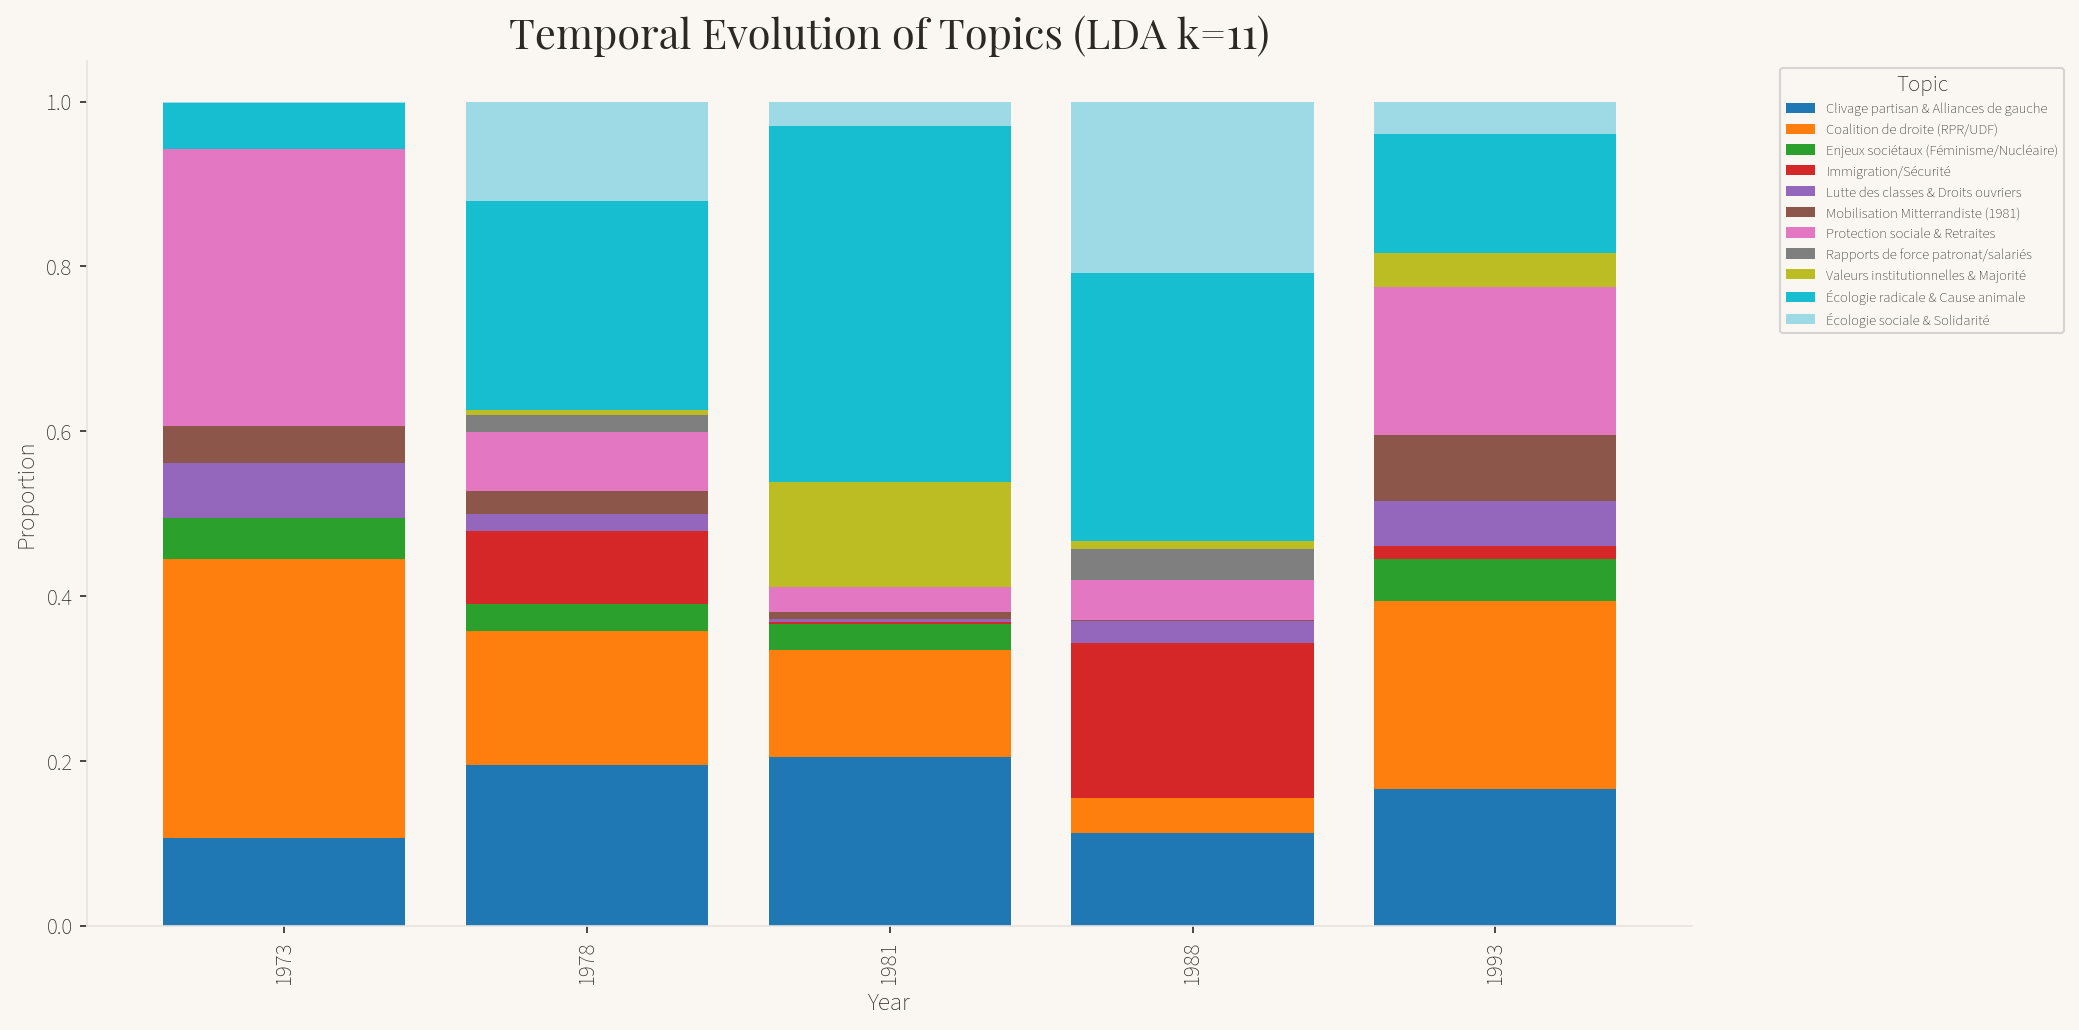

In [27]:
ct_time = pd.crosstab(df_topic['year'], df_topic[topic_col], normalize='index')
fig, ax = plt.subplots(figsize=(14, 7))
ct_time.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)
ax.set_title(f'Temporal Evolution of Topics ({PRIMARY} k={N_PRIMARY})',
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Proportion')
ax.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig("../data/temporal_evolution.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

The stacked bar chart reveals how the thematic composition of electoral discourse shifts across the five elections. Themes that grow (e.g., ecology, immigration) reflect the changing salience of political issues from the late Gaullist era through the Mitterrand years (1973–1993), a period marked by the oil shock, economic crisis, European integration, and the rise of the far right.

### 7.2 Topics × political family

=== Topic distribution by political family ===

lda_topic_name     Clivage partisan & Alliances de gauche  Coalition de droite (RPR/UDF)  Enjeux sociétaux (Féminisme/Nucléaire)  Immigration/Sécurité  Lutte des classes & Droits ouvriers  Mobilisation Mitterrandiste (1981)  Protection sociale & Retraites  Rapports de force patronat/salariés  Valeurs institutionnelles & Majorité  Écologie radicale & Cause animale  Écologie sociale & Solidarité
famille_politique                                                                                                                                                                                                                                                                                                                                                                                           
Gauche radicale                                     0.157                          0.186                                   0.037                 0.050        

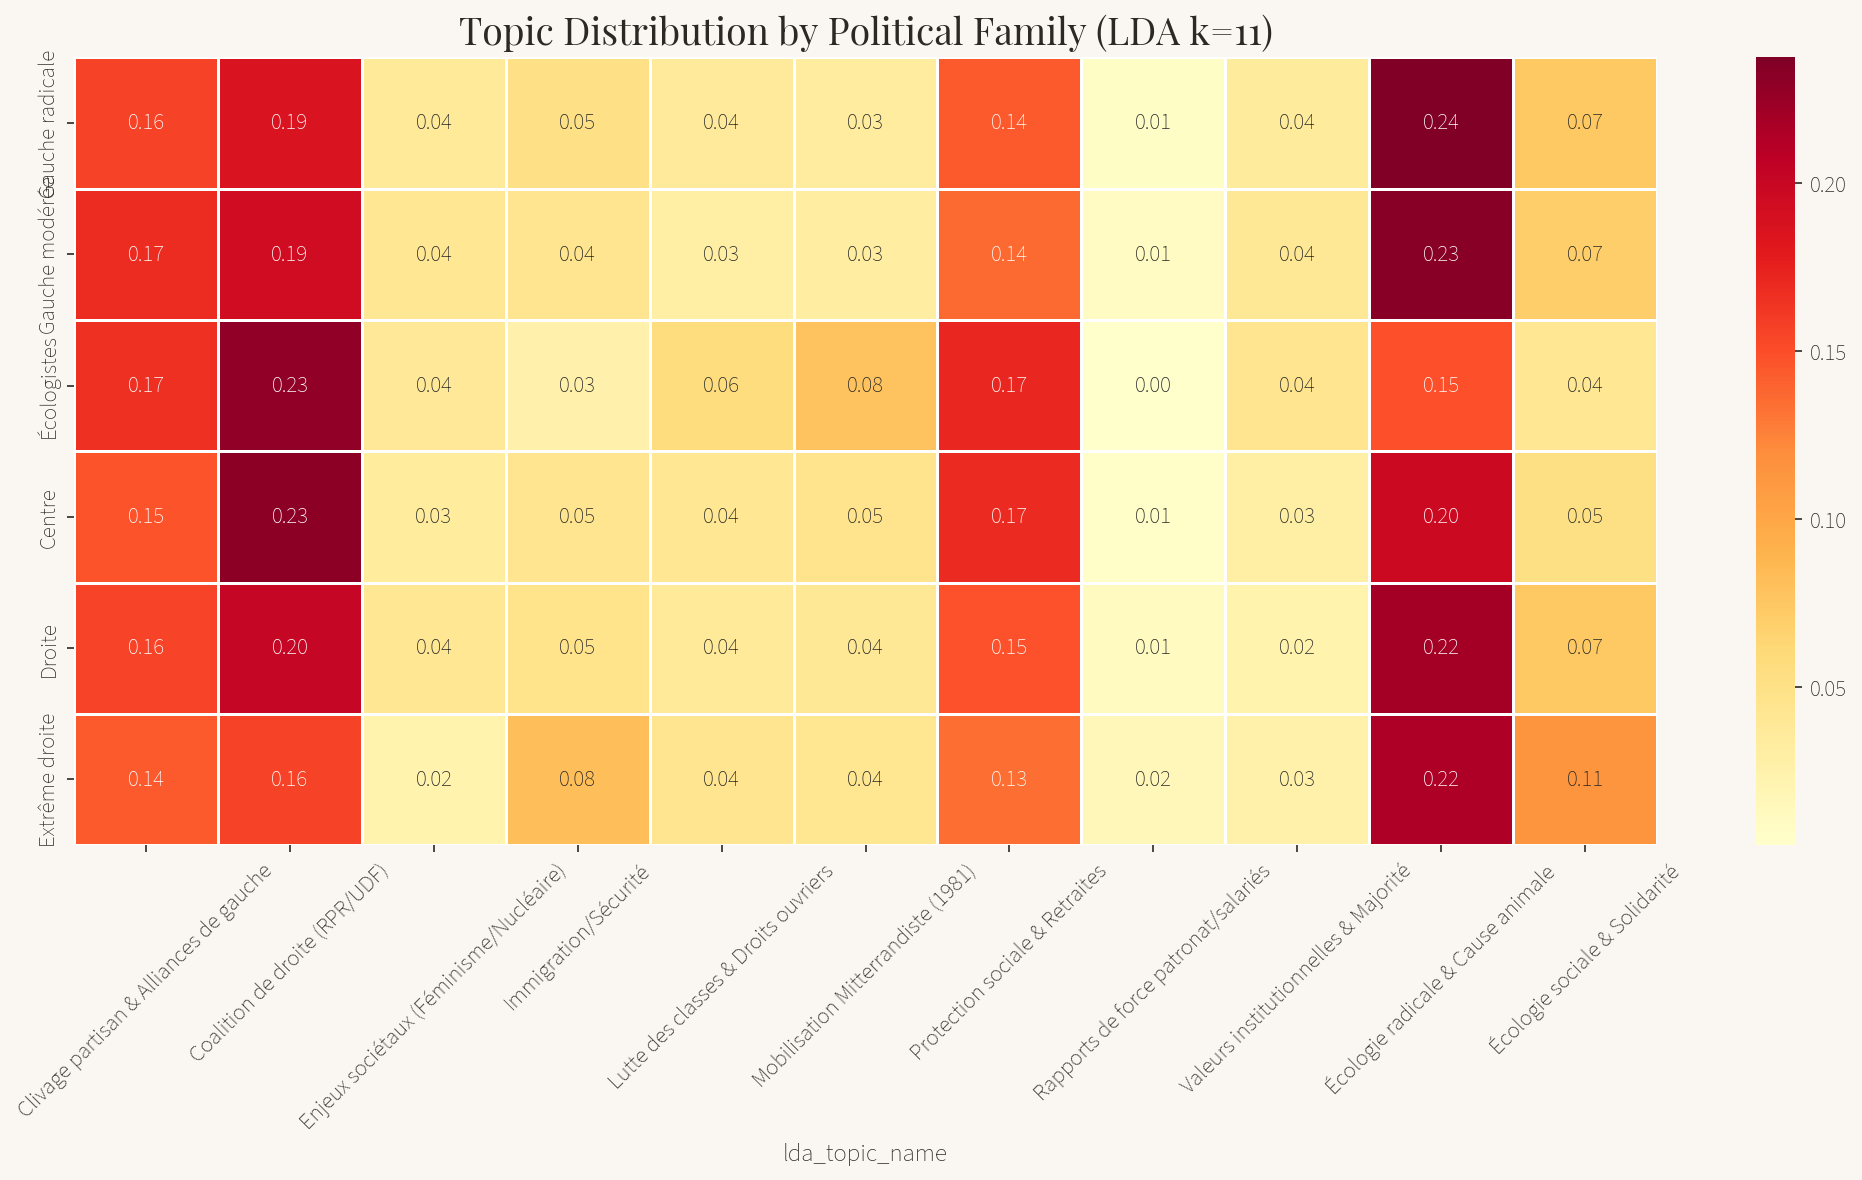

In [28]:
# Filter to classified families only
df_fam = df_topic[df_topic['famille_politique'].isin(FAMILIES)].copy()

ct_family = pd.crosstab(df_fam['famille_politique'], df_fam[topic_col], normalize='index')
ct_family = ct_family.reindex([f for f in FAMILIES if f in ct_family.index])

# Print statistics
print("=== Topic distribution by political family ===\n")
print(ct_family.round(3).to_string())

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(ct_family, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title(f'Topic Distribution by Political Family ({PRIMARY} k={N_PRIMARY})',
             fontfamily=FONT_TITLE, fontsize=18, fontweight='bold')
ax.set_ylabel(''); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("../data/topics_by_party.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 7.3 Political family specialization (over/under-representation)

The specialization ratio divides each family's topic share by the corpus-wide average. Values above 1 indicate **over-representation** (the family talks about this theme more than average), below 1 indicates **under-representation**. This follows Grimmer & Stewart's (2013) framework for political text analysis.

=== Specialization ratio by political family (>1 = over-represented) ===

lda_topic_name     Clivage partisan & Alliances de gauche  Coalition de droite (RPR/UDF)  Enjeux sociétaux (Féminisme/Nucléaire)  Immigration/Sécurité  Lutte des classes & Droits ouvriers  Mobilisation Mitterrandiste (1981)  Protection sociale & Retraites  Rapports de force patronat/salariés  Valeurs institutionnelles & Majorité  Écologie radicale & Cause animale  Écologie sociale & Solidarité
famille_politique                                                                                                                                                                                                                                                                                                                                                                                           
Gauche radicale                                      1.00                           0.95                                    0.99    

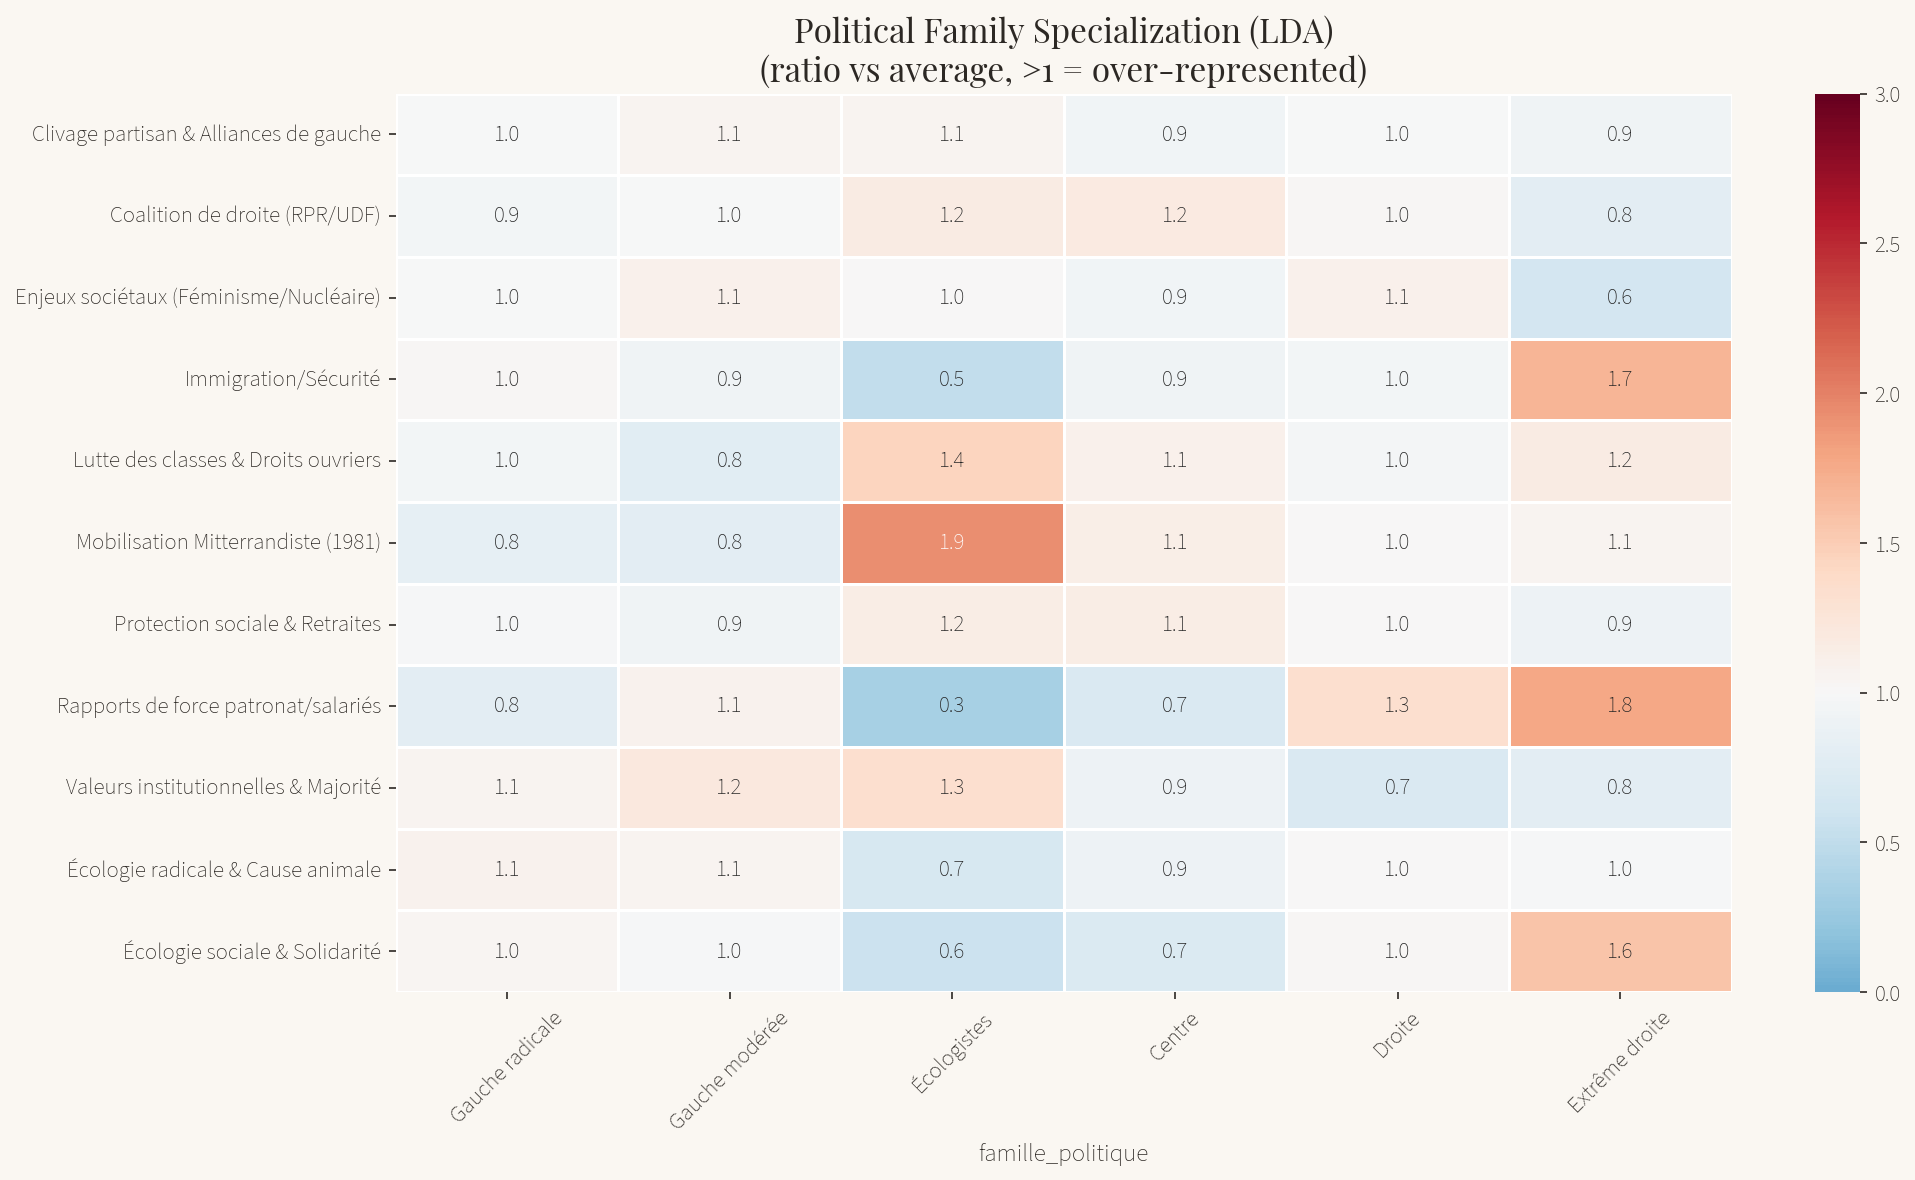

In [29]:
topic_marginal = df_fam[topic_col].value_counts(normalize=True).sort_index()
spec = ct_family.div(topic_marginal, axis=1)

# Print statistics
print("=== Specialization ratio by political family (>1 = over-represented) ===\n")
print(spec.round(2).to_string())

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(spec.T, annot=True, fmt='.1f', cmap='RdBu_r', center=1.0,
            linewidths=0.5, ax=ax, vmin=0, vmax=3)
ax.set_title(f'Political Family Specialization ({PRIMARY})\n(ratio vs average, >1 = over-represented)',
             fontfamily=FONT_TITLE, fontsize=16, fontweight='bold')
ax.set_ylabel(''); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("../data/party_specialization.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 7.4 Dynamic specialization: political family × year

This is the most analytically rich visualization because it shows how each political family's thematic specialization **evolves** across the five elections. A family whose specialization shifts between 1973 and 1993 is adapting its discourse to changing political context.

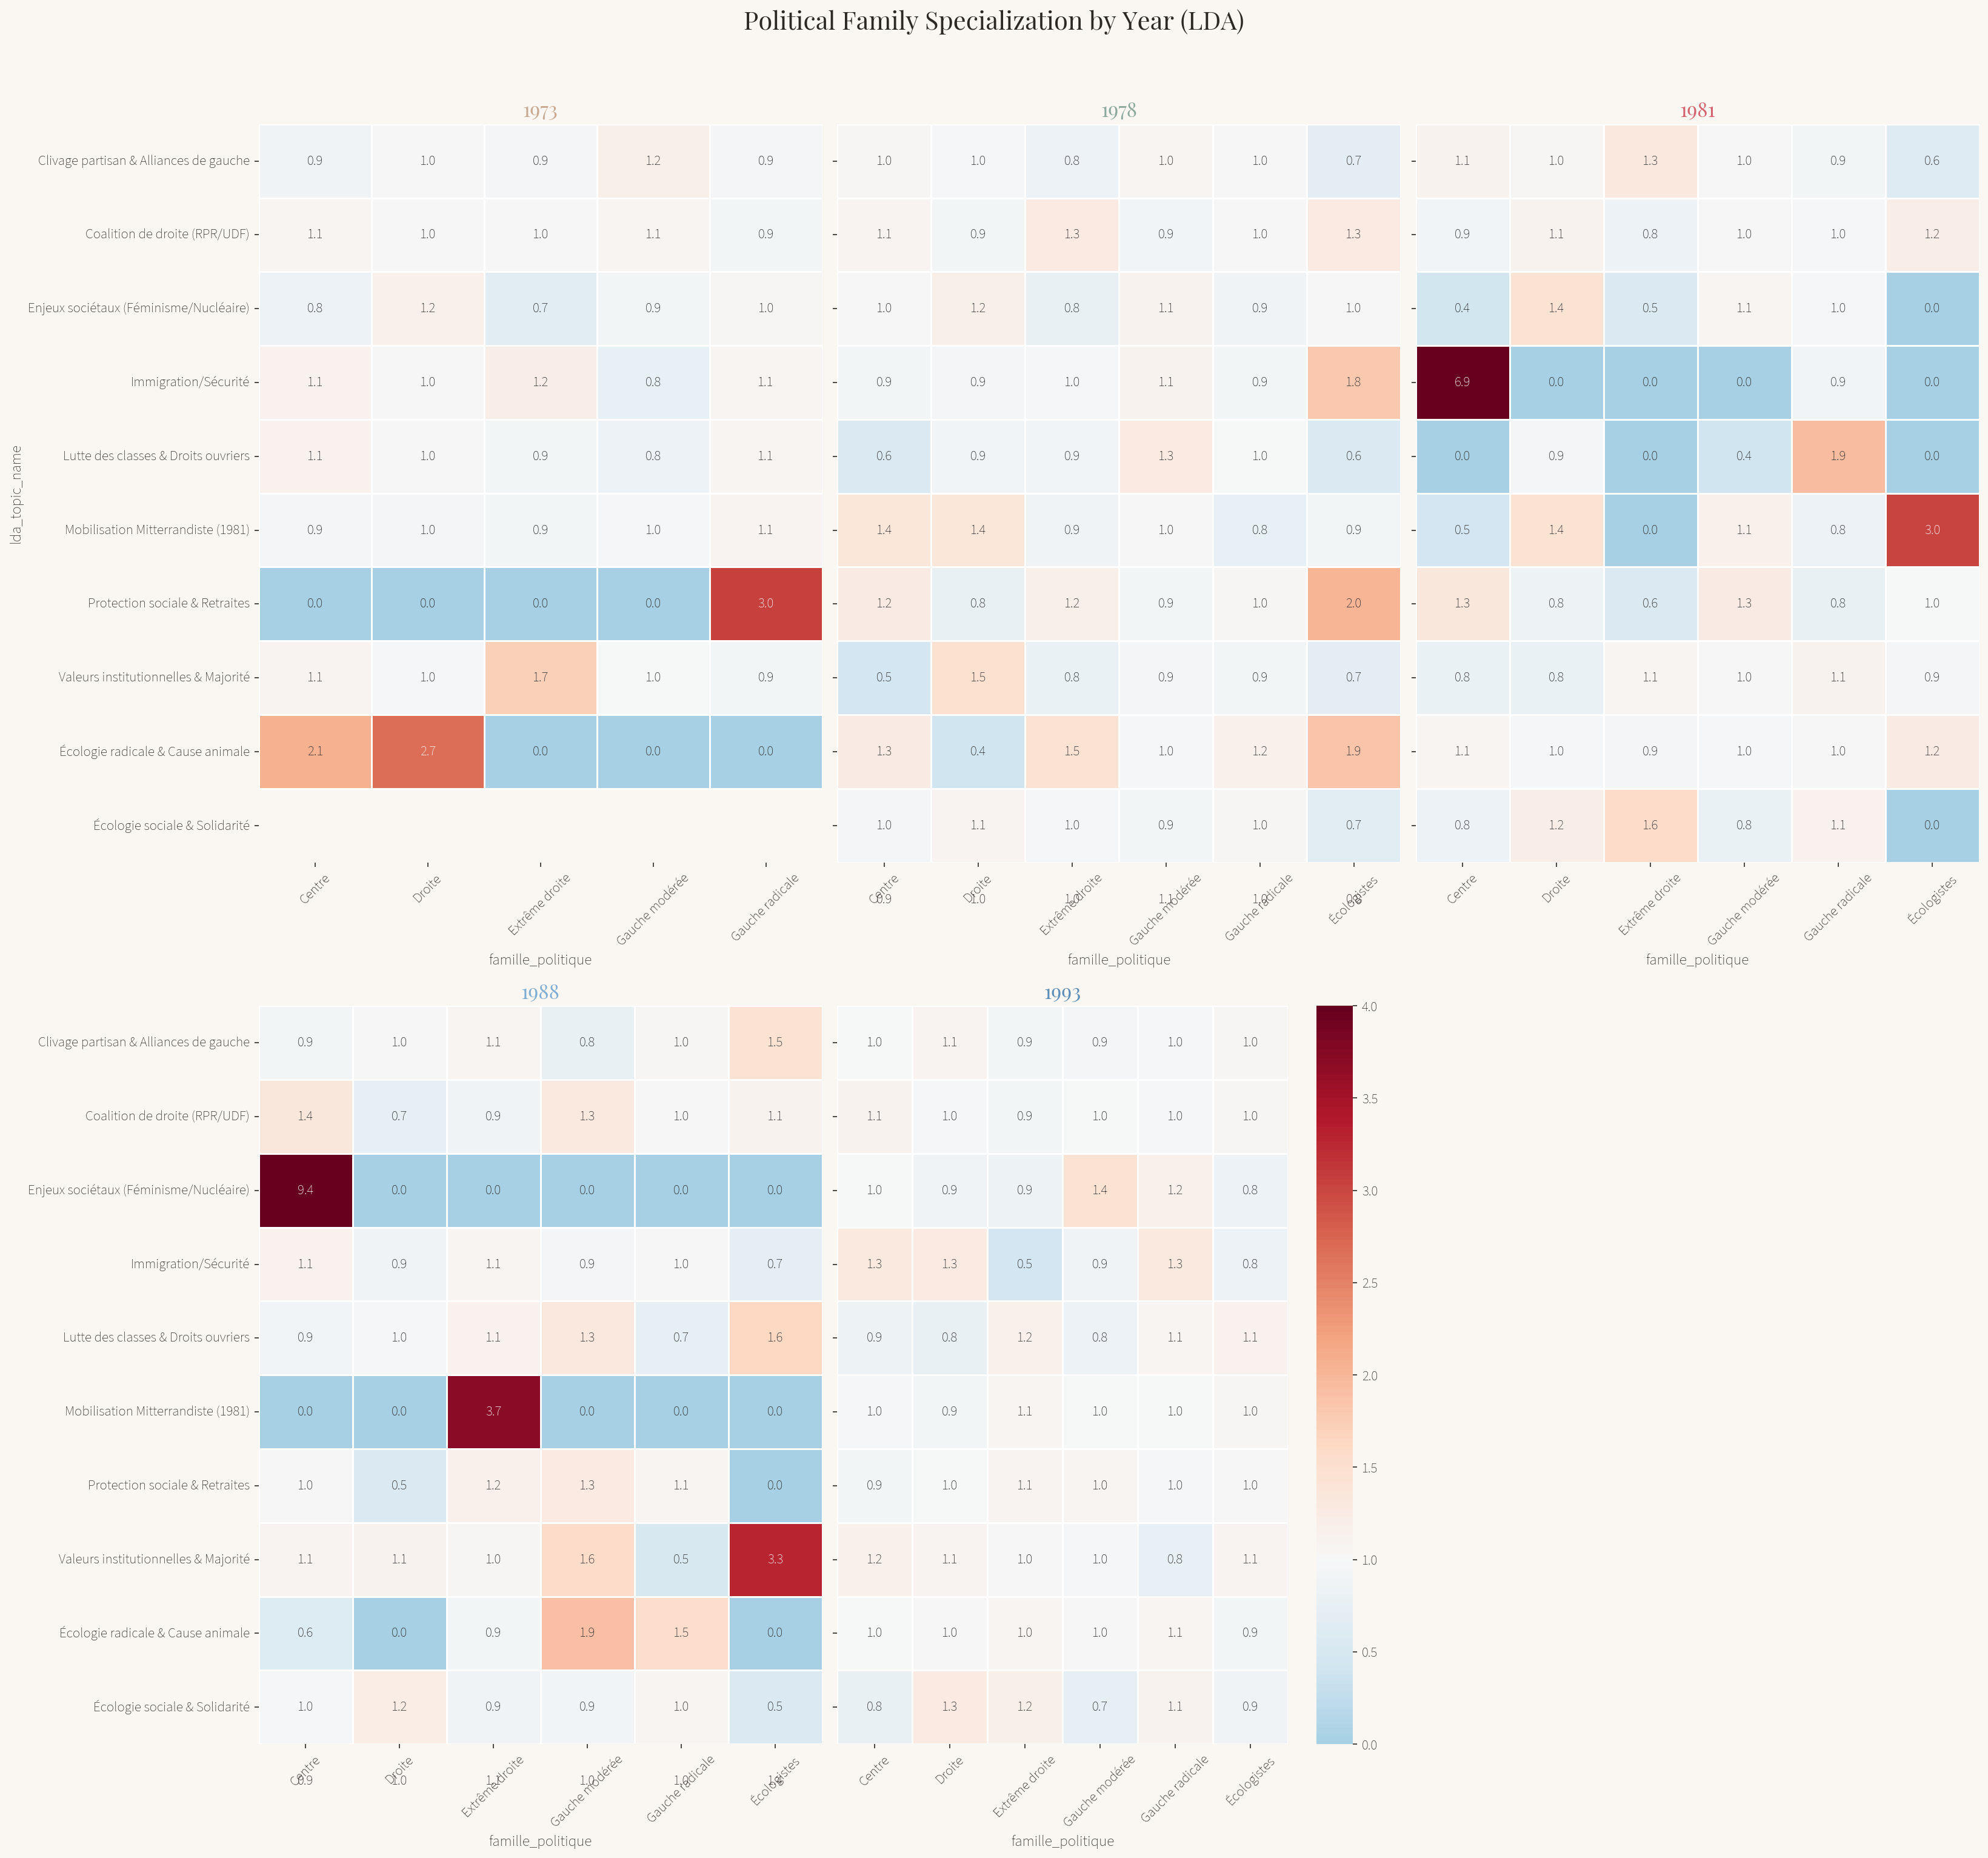

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(22, 20), sharey=True)
axes = axes.flatten()
for i, year in enumerate(sorted(df_topic['year'].unique())):
    df_y = df_topic[(df_topic['year'] == year) & (df_topic['famille_politique'].isin(FAMILIES))]
    if df_y.empty: continue
    marg = df_y[topic_col].value_counts(normalize=True).sort_index()
    ct_y = pd.crosstab(df_y['famille_politique'], df_y[topic_col], normalize='index')
    ct_y = ct_y.reindex(columns=marg.index, fill_value=0)
    spec_y = ct_y.div(marg, axis=1)
    sns.heatmap(spec_y.T, annot=True, fmt='.1f', cmap='RdBu_r', center=1.0,
                linewidths=0.5, ax=axes[i], vmin=0, vmax=4, cbar=(i==4))
    axes[i].set_title(f'{year}', fontfamily=FONT_TITLE, fontsize=16, fontweight='bold',
                      color=YEAR_COLORS.get(str(year), TEXT_COLOR))
    axes[i].tick_params(axis='x', rotation=45)
    if i > 0: axes[i].set_ylabel('')
axes[5].set_visible(False)
plt.suptitle(f'Political Family Specialization by Year ({PRIMARY})',
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../data/specialization_by_year.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 7.5 Topics × gender

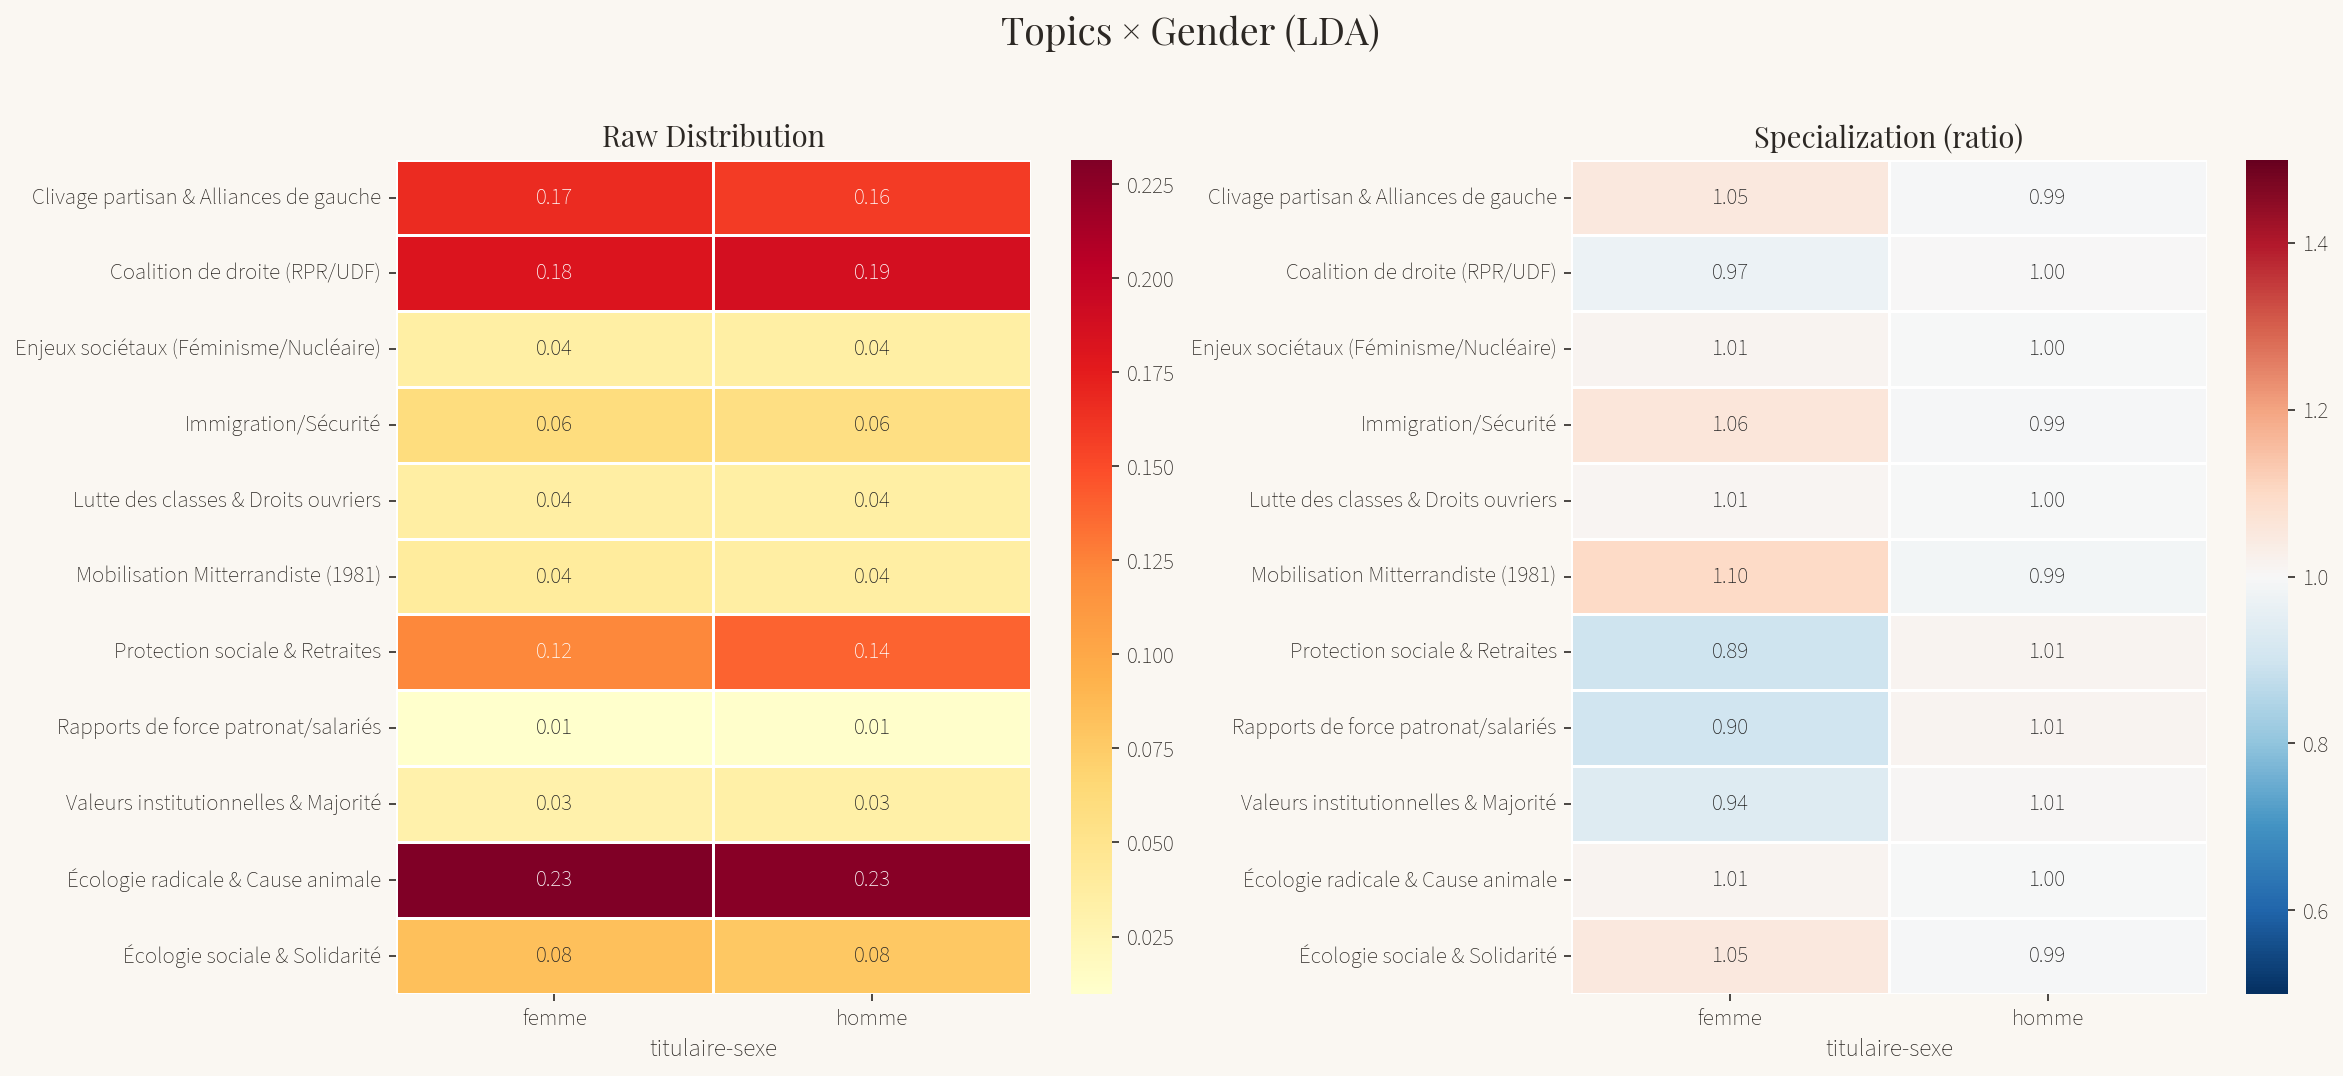

In [31]:
if 'titulaire-sexe' in df_topic.columns:
    df_gender = df_topic[df_topic['titulaire-sexe'].isin(['homme', 'femme'])]
    ct_gender = pd.crosstab(df_gender['titulaire-sexe'], df_gender[topic_col], normalize='index')
    marg_gender = df_gender[topic_col].value_counts(normalize=True).sort_index()
    spec_gender = ct_gender.div(marg_gender, axis=1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    sns.heatmap(ct_gender.T, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=axes[0])
    axes[0].set_title('Raw Distribution', fontfamily=FONT_TITLE, fontsize=14); axes[0].set_ylabel('')
    sns.heatmap(spec_gender.T, annot=True, fmt='.2f', cmap='RdBu_r', center=1.0,
                linewidths=0.5, ax=axes[1], vmin=0.5, vmax=1.5)
    axes[1].set_title('Specialization (ratio)', fontfamily=FONT_TITLE, fontsize=14); axes[1].set_ylabel('')
    plt.suptitle(f'Topics × Gender ({PRIMARY})', fontfamily=FONT_TITLE, fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("../data/topics_by_gender.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
    plt.show()

### 7.6 Topics × profession (PCS categories)

Using the BERT-classified PCS categories from Notebook 02, we test whether candidates' professional backgrounds predict their thematic focus. This is one of the most original aspects of our analysis, moving beyond party-level patterns to individual-level socio-demographic correlates.

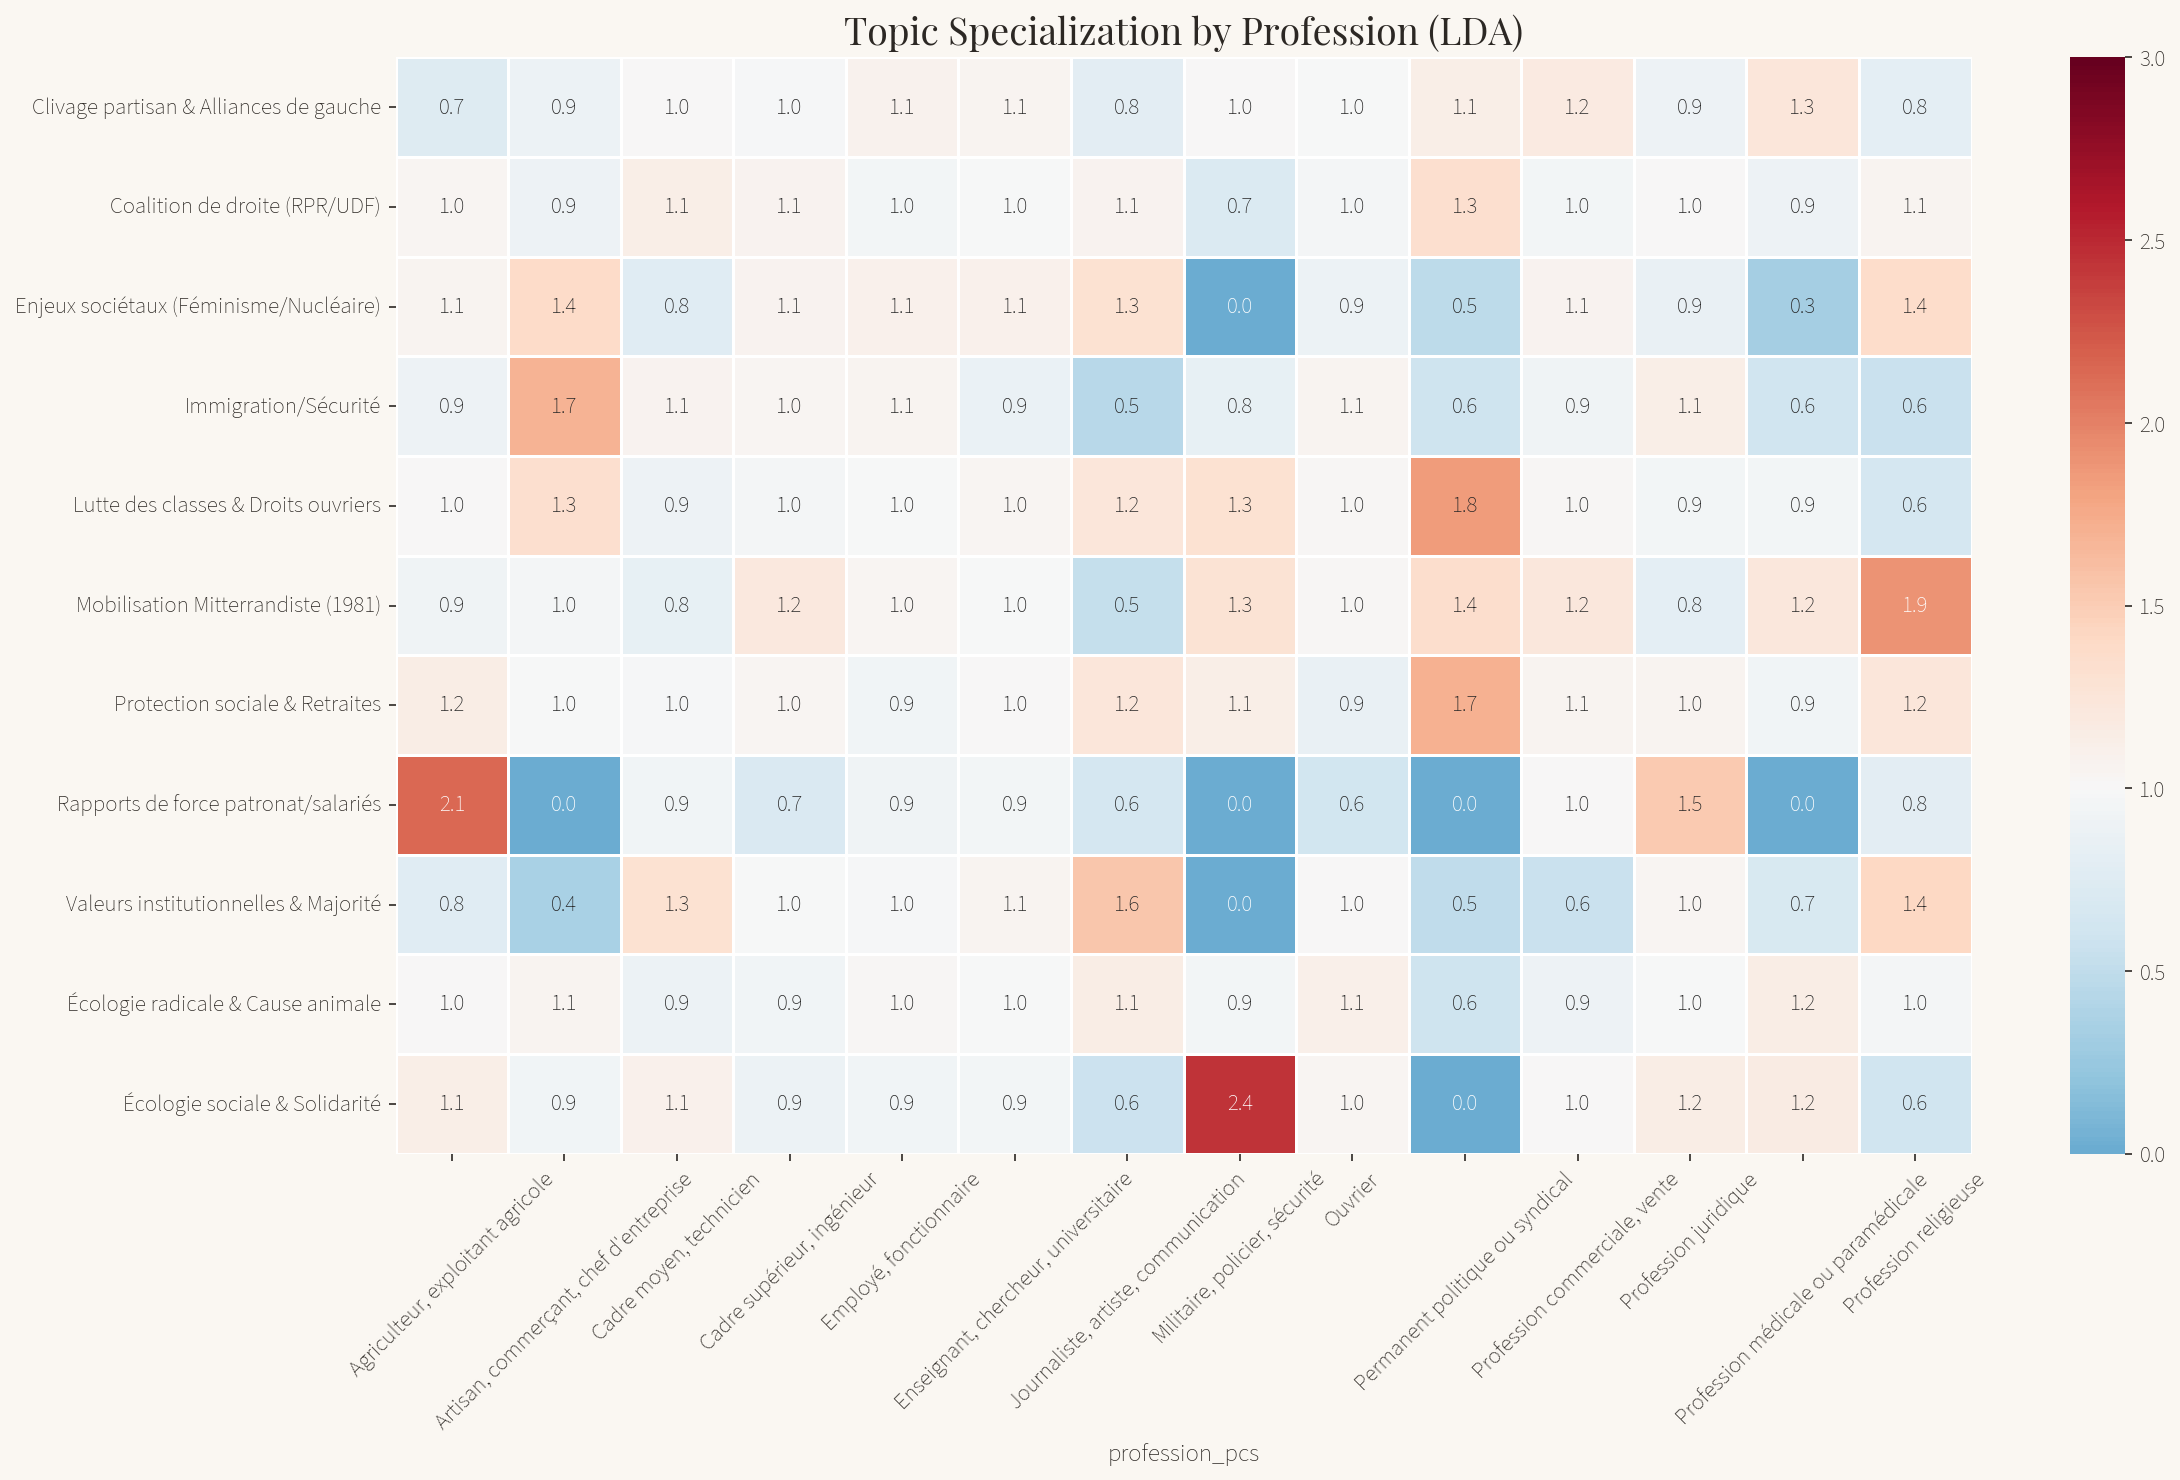

In [32]:
if 'profession_pcs' in df_topic.columns:
    df_prof = df_topic[df_topic['profession_pcs'] != 'Non renseigné']
    pcs_keep = df_prof['profession_pcs'].value_counts()
    pcs_keep = pcs_keep[pcs_keep >= 30].index
    df_prof = df_prof[df_prof['profession_pcs'].isin(pcs_keep)]
    ct_prof = pd.crosstab(df_prof['profession_pcs'], df_prof[topic_col], normalize='index')
    marg_prof = df_prof[topic_col].value_counts(normalize=True).sort_index()
    spec_prof = ct_prof.div(marg_prof, axis=1)
    fig, ax = plt.subplots(figsize=(16, 10))
    sns.heatmap(spec_prof.T, annot=True, fmt='.1f', cmap='RdBu_r', center=1.0,
                linewidths=0.5, ax=ax, vmin=0, vmax=3)
    ax.set_title(f'Topic Specialization by Profession ({PRIMARY})',
                 fontfamily=FONT_TITLE, fontsize=18, fontweight='bold')
    ax.set_ylabel(''); ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig("../data/topics_by_profession.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
    plt.show()
else:
    print("profession_pcs not found - run Notebook 02")

### 7.7 Topics x age bracket

The metadata field  allows us to test whether a candidate's generational position correlates with thematic emphasis. Age is a sociologically relevant variable in political discourse: younger candidates may focus on education and employment, while older candidates may emphasize institutional stability and defense. This cross-referencing of topics with metadata follows the course's emphasis on using topic distributions as a basis for further analysis. (Ref: Lecon 6 - Topic Modelling)

Documents with valid age bracket: 7,685


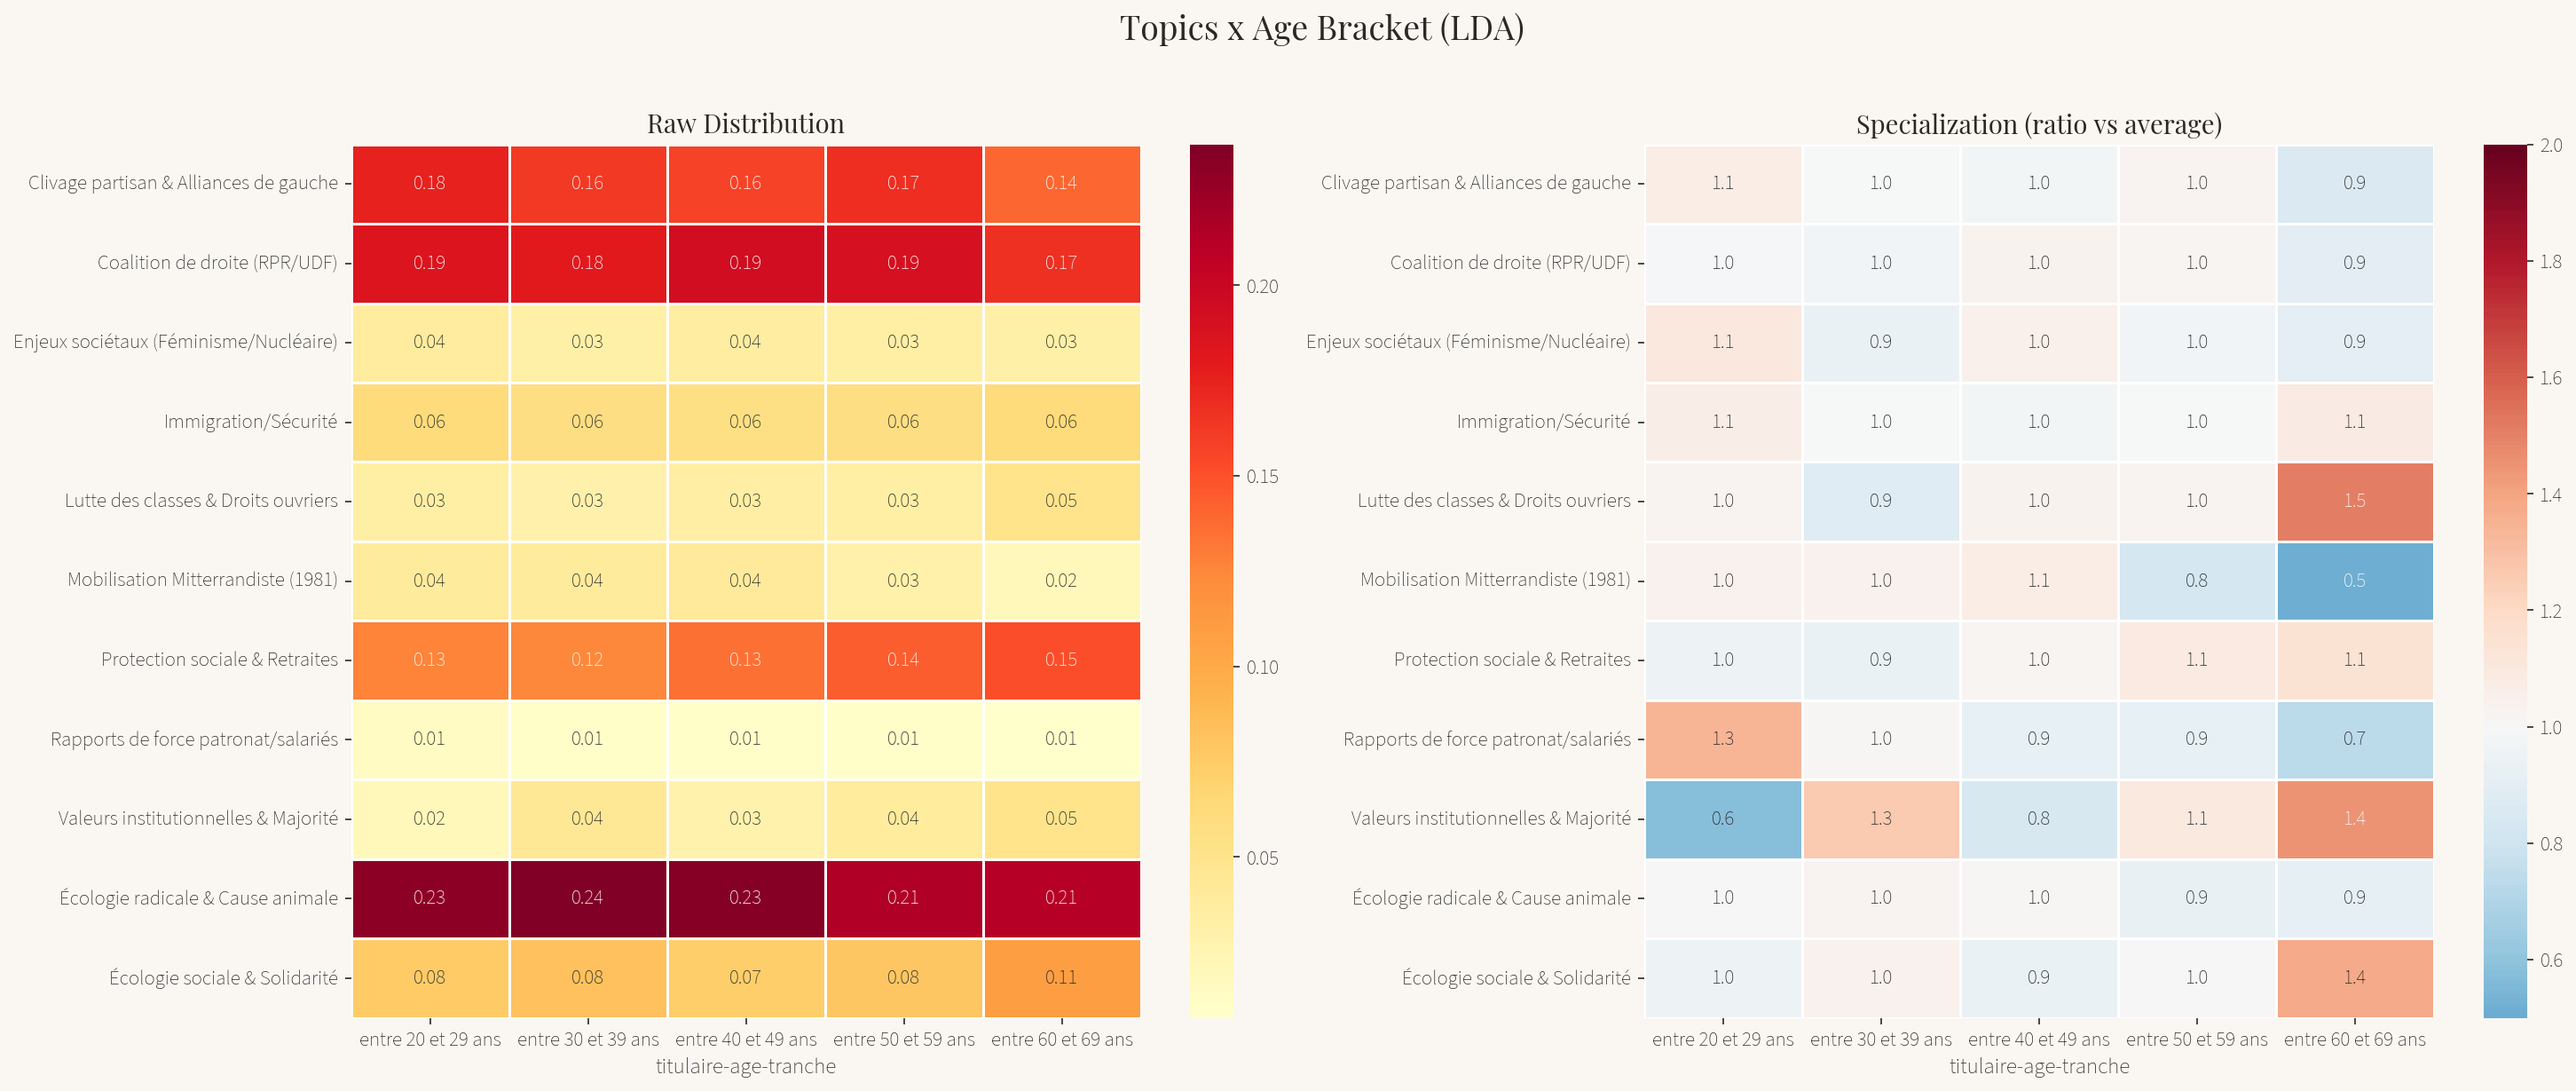

In [33]:
if "titulaire-age-tranche" in df_topic.columns:
    age_valid = ["entre 20 et 29 ans", "entre 30 et 39 ans",
                "entre 40 et 49 ans", "entre 50 et 59 ans",
                "entre 60 et 69 ans"]
    df_age = df_topic[df_topic["titulaire-age-tranche"].isin(age_valid)].copy()
    print(f"Documents with valid age bracket: {len(df_age):,}")

    ct_age = pd.crosstab(df_age["titulaire-age-tranche"], df_age[topic_col], normalize="index")
    ct_age = ct_age.reindex(age_valid)
    marg_age = df_age[topic_col].value_counts(normalize=True).sort_index()
    spec_age = ct_age.div(marg_age, axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.heatmap(ct_age.T, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, ax=axes[0])
    axes[0].set_title("Raw Distribution", fontfamily=FONT_TITLE, fontsize=14)
    axes[0].set_ylabel("")
    sns.heatmap(spec_age.T, annot=True, fmt=".1f", cmap="RdBu_r", center=1.0,
                linewidths=0.5, ax=axes[1], vmin=0.5, vmax=2.0)
    axes[1].set_title("Specialization (ratio vs average)", fontfamily=FONT_TITLE, fontsize=14)
    axes[1].set_ylabel("")
    plt.suptitle(f"Topics x Age Bracket ({PRIMARY})",
                 fontfamily=FONT_TITLE, fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("../data/topics_by_age.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
else:
    print("titulaire-age-tranche not found")

**Age-theme correlations.** The specialization heatmap reveals whether generational effects structure political discourse. Younger candidates (20-29, 30-39) may over-represent topics related to education, employment, and social change, while older candidates (50+) may emphasize institutional themes, defense, and established party lines. Note that the age data covers only ~38% of the corpus ( dominates), so these patterns should be interpreted as suggestive rather than definitive. The missing data is non-random: earlier elections (1973, 1978) have less systematic age recording, which may introduce a temporal bias. (Ref: Lecon 6 - Topic Modelling)

---
## 8. Save & Summary

In [34]:
df_topic.to_pickle("../data/df_topics.pkl")
with open("../data/models_topic.pkl", "wb") as f:
    pickle.dump({
        'lda_baseline': lda_baseline, 'lda_final': lda_final, 'nmf_final': nmf_final,
        'tfidf_vectorizer': tfidf_vec_clean, 'gensim_dictionary': gensim_dictionary,
        'K_LDA': K_LDA, 'K_NMF': K_NMF, 'PRIMARY': PRIMARY,
        'TOPIC_NAMES_LDA': TOPIC_NAMES_LDA, 'TOPIC_NAMES_NMF': TOPIC_NAMES_NMF,
        'FAMILIES': FAMILIES,
        'comparison': comparison,
    }, f)
print(f"DataFrame: {len(df_topic):,} rows")
print(f"Models saved | LDA k={K_LDA} | NMF k={K_NMF} | Primary: {PRIMARY}")
print(f"Political families: {FAMILIES}")

DataFrame: 21,139 rows
Models saved | LDA k=11 | NMF k=5 | Primary: LDA
Political families: ['Gauche radicale', 'Gauche modérée', 'Écologistes', 'Centre', 'Droite', 'Extrême droite']


---
## Summary

### Methodology

| Step | Method | Reference |
|------|--------|----------|
| Text preparation | Lowercasing, punctuation/digit removal, German filtering | Standard NLP preprocessing |
| Lemmatization | spaCy `fr_core_news_md` | Lecon 4 - Computational Linguistics |
| Baseline LDA | sklearn LDA k=12, full vocabulary | Diagnostic of partisan vocabulary bias |
| Partisan stopwords | Extended custom list (party names, leaders, cross-partisan terms, OCR artifacts) | Lecon 1 - Vector Representation |
| LDA grid search | gensim LdaMulticore, $C_v$ coherence | Lecon 6 - Topic Modelling; Röder et al., 2015 |
| NMF grid search | sklearn NMF, TF-IDF (`min_df=15`, `max_features=3000`) | Lecon 6 - Topic Modelling |
| BERTopic | Sentence-Transformers + UMAP + HDBSCAN (optional) | Lecon 7 - Transformers; Grootendorst, 2022 |
| Model selection | $C_v$ coherence + distribution balance | LDA k=11 selected; NMF rejected (degenerate) |
| Cross-analysis | Topics × political family / year / gender / profession / age | 6 visualizations |

### Key findings

- LDA k=11 produces well-differentiated topics covering economic conflict, institutional values, ecology, immigration, and social protection.
- Political family specialization reveals clear thematic profiles: the *gauche radicale* focuses on class struggle, the *extrême droite* on immigration/security, *écologistes* on environmental themes.
- Temporal shifts capture real political dynamics: the rise of immigration discourse after 1981, the growing salience of ecology in 1993.

### References

- Blei, D. M. (2012). Probabilistic topic models. *Communications of the ACM*, 55(4), 77–84.
- Röder, M., Both, A., & Hinneburg, A. (2015). Exploring the space of topic coherence measures. *WSDM '15*.
- Grootendorst, M. (2022). BERTopic: Neural topic modeling with a class-based TF-IDF procedure. *arXiv:2203.05794*.